### All imports

In [1]:
from time import strftime, time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import torch
except ImportError:
    torch = None
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.backend import BackendPolicy, backend
from src.layers import ELU, BatchNormalization, Conv1D, Dense, Dropout, GlobalConcatPool1D, LeakyReLU, Softmax
from src.loss.cross_entropy import CrossEntropy
from src.models import Network, Sequential
from src.models.history import TrainingHistory
from src.optimizer import Adam

### Util function for loading and preparing the dataset
The `prepare_har_dataset` function converts raw CSV data into structured, model-ready tensors. It handles the "heavy lifting" such as:
- Reshaping the flat vectors into 3D shape (Samples, Channels, Time Steps)
- Providing Accelerometer and Gyroscope rotation-invariant features as additional channels
- Normalizing the data

The `remap_dataset` is a utility function that allows to filter or re-index the labels for specific experiments (e.g. combining sit and sit-talk into one "sit" class).

In [2]:
def prepare_har_dataset(
    csv_path: str, mode: Literal["raw", "mag", "hybrid"] = "hybrid", shuffle: bool = True, random_state: int | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    """
    Loads the HAR dataset from a CSV file and prepares it for training.
    Args:
        csv_path: Path to the CSV file containing the dataset.
        mode: Determines the type of features to prepare. Options are:
            - 'raw': Use only the raw accelerometer and gyroscope data (6 channels).
            - 'mag': Use only the magnitude of accelerometer and gyroscope data (2 channels).
            - 'hybrid': Use both raw and magnitude features (8 channels).
    """
    raw_data = np.genfromtxt(csv_path, delimiter=",")
    Y = raw_data[:, 9000].astype("int32")
    features_raw = raw_data[:, :9000].astype("float32")
    lengths = raw_data[:, 9001].astype("float32")
    num_samples = features_raw.shape[0]
    time_steps = 1500

    X_6 = np.zeros((num_samples, time_steps, 6), dtype="float32")
    for i in range(6):
        X_6[:, :, i] = features_raw[:, i * time_steps : (i + 1) * time_steps]

    acc_mag = np.linalg.norm(X_6[:, :, 0:3], axis=2, keepdims=True)
    gyro_mag = np.linalg.norm(X_6[:, :, 3:6], axis=2, keepdims=True)

    if mode == "raw":
        X_data = X_6
    elif mode == "mag":
        X_data = np.concatenate([acc_mag, gyro_mag], axis=2)
    else:
        X_data = np.concatenate([X_6, acc_mag, gyro_mag], axis=2)

    num_ch = X_data.shape[2]
    scaler = StandardScaler()
    X_flat = X_data.reshape(-1, num_ch)
    X_scaled_flat = scaler.fit_transform(X_flat)
    X_final = X_scaled_flat.reshape(num_samples, time_steps, num_ch)
    mask = np.arange(time_steps) < lengths[:, None]
    X_final[~mask] = 0.0
    X_final = np.transpose(X_final, (0, 2, 1))
    if shuffle:
        indices = np.arange(num_samples)
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(indices)
        X_final = X_final[indices]
        Y = Y[indices]
        lengths = lengths[indices]

    return X_final, Y, lengths, scaler


def remap_dataset(
    X: np.ndarray, Y: np.ndarray, lengths: np.ndarray, config: dict[int, str]
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str]]:
    """
    Remaps the dataset labels according to the provided configuration.
    Args:
        X: Input features.
        Y: Original labels.
        lengths: Lengths of each sequence.
        config: Mapping of old labels to new labels.
    Returns:
        Remapped features, labels, lengths, and unique labels.
    """
    new_X, new_Y, new_lengths = [], [], []
    unique_labels = sorted(set(config.values()))
    label_to_id = {name: i for i, name in enumerate(unique_labels)}
    for i in range(len(Y)):
        old_id = int(Y[i])
        if old_id in config:
            new_X.append(X[i])
            new_lengths.append(lengths[i])
            new_Y.append(label_to_id[config[old_id]])
    return np.array(new_X), np.array(new_Y), np.array(new_lengths), unique_labels


def prepare_model(labels: list, scaler: StandardScaler, lr: float = 1e-3) -> Network:
    optimizer = Adam(learning_rate=lr)
    loss_fn = CrossEntropy()
    model = Sequential(
        [
            Conv1D(filters=32, kernel_size=31, stride=1, padding=15, name="conv1"),
            BatchNormalization(name="bn1"),
            LeakyReLU(name="leaky_relu1"),
            Conv1D(filters=64, kernel_size=15, stride=2, padding=7, name="conv2"),
            BatchNormalization(name="bn2"),
            LeakyReLU(name="leaky_relu2"),
            Dropout(0.2, name="dropout1"),
            Conv1D(filters=128, kernel_size=7, stride=2, padding=3, name="conv3"),
            BatchNormalization(name="bn3"),
            ELU(name="elu1"),
            GlobalConcatPool1D(name="masked_gap"),
            Dense(128, name="dense1"),
            BatchNormalization(name="bn4"),
            ELU(name="elu2"),
            Dropout(0.5, name="dropout2"),
            Dense(len(labels), name="dense2"),
            Softmax(name="softmax"),
        ]
    )
    model.compile(optimizer=optimizer, loss=loss_fn)
    model.activity_labels = labels
    model.scaler = scaler
    return model


def to_one_hot(Y, num_classes):
    return np.eye(num_classes)[Y.astype(int)]

In [3]:
def plot_training_history(history):
    sns.set_style("whitegrid")
    train_losses = history.metrics["train_loss"]
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.plot(epochs, train_losses, label="Train Loss", marker="o", markersize=4, alpha=0.7)
    has_val = "val_loss" in history.metrics and len(history.metrics["val_loss"]) > 0
    if has_val:
        val_losses = history.metrics["val_loss"]
        ax1.plot(epochs, val_losses, label="Val Loss", marker="s", markersize=4, color="orange")
        if history.best_epoch is not None:
            best_x = history.best_epoch + 1
            best_y = val_losses[history.best_epoch]
            ax1.axvline(x=best_x, color="red", linestyle="--", alpha=0.6, label="Best Epoch")
            ax1.scatter(best_x, best_y, color="red", marker="*", s=100, zorder=5)

    title = f"Training"
    if has_val:
        title += " and Validation"
    title += " Loss"

    ax1.set_title(title, fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    if "train_acc" in history.metrics:
        ax2.plot(epochs, history.metrics["train_acc"], label="Train Acc", marker="o", markersize=4, alpha=0.7)

    if "val_acc" in history.metrics and len(history.metrics["val_acc"]) > 0:
        val_accs = history.metrics["val_acc"]
        ax2.plot(epochs, val_accs, label="Val Acc", marker="s", markersize=4, color="green")
        if history.best_epoch is not None:
            best_x = history.best_epoch + 1
            ax2.axvline(x=best_x, color="red", linestyle="--", alpha=0.6, label="Best Epoch")

    title = f"Training"
    if has_val:
        title += " and Validation"
    title += " Accuracy"
    ax2.set_title(title, fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model, lengths_test, activity_map):
    cm = confusion_matrix(y_true, y_pred)
    num_classes = len(activity_map)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[activity_map[i] for i in range(num_classes)],
        yticklabels=[activity_map[i] for i in range(num_classes)],
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()


def get_detailed_metrics(y_test, y_pred_probs, activity_map):
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=[activity_map[i] for i in range(len(activity_map))],
        output_dict=True,
        zero_division=0,
    )
    global_metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": report["macro avg"]["f1-score"],
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
    }

    df_classes = pd.DataFrame(report).transpose()
    df_classes = df_classes.drop(["macro avg", "weighted avg"], errors="ignore")

    return global_metrics, df_classes


def plot_class_performance(df_classes, metric: Literal["precision", "recall", "f1-score", "support"] = "f1-score"):
    valid_metrics = df_classes.columns.tolist()
    if metric not in valid_metrics:
        raise ValueError(f"Invalid metric '{metric}'. Choose from {valid_metrics}")

    plt.figure(figsize=(12, 8))
    df_sorted = df_classes.sort_values(by=metric, ascending=True)
    colors = sns.color_palette("RdYlGn", len(df_sorted))
    ax = sns.barplot(x=df_sorted[metric], y=df_sorted.index, palette=colors, hue=df_sorted.index, legend=False)
    mean_val = df_sorted[metric].mean()
    plt.axvline(x=mean_val, color="blue", linestyle="--", label=f"Mean {metric.capitalize()} ({mean_val:.2f})")
    plt.title(f"{metric.capitalize()} per Activity", fontsize=15, fontweight="bold")
    plt.xlabel(metric.capitalize())
    plt.ylabel("Activity")
    if metric != "support":
        plt.xlim(0, 1.05)

    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_most_confused_classes(df_classes, top_n=5):
    df_classes["error_rate"] = 1 - df_classes["recall"]
    df_err = df_classes.sort_values(by="error_rate", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.barplot(x=df_err["error_rate"], y=df_err.index, palette="Reds_r", hue=df_err.index, legend=False)

    ax.bar_label(ax.containers[0], fmt=lambda x: f"{x * 100:.1f}%", padding=8, fontweight="bold", fontsize=11)

    plt.title(f"Top {top_n} Most Confused Activities (By Total Misses)", fontsize=15, fontweight="bold")
    plt.xlabel("Error Rate (1 - Recall)")
    plt.ylabel("Activity")
    plt.xlim(0, 1.1)

    plt.tight_layout()
    plt.show()


def plot_top_mutual_confusions(y_test, y_pred_probs, activity_map, top_n=10):
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    mutual_confusions = []
    num_classes = len(activity_map)
    for i in range(num_classes):
        for j in range(i + 1, num_classes):
            combined_error = cm_norm[i, j] + cm_norm[j, i]

            mutual_confusions.append(
                {"Class_A": activity_map[i], "Class_B": activity_map[j], "Mutual_Error": combined_error}
            )

    mutual_df = pd.DataFrame(mutual_confusions).sort_values(by="Mutual_Error", ascending=False).head(top_n)
    mutual_df["Pair"] = mutual_df["Class_A"] + " ↔ " + mutual_df["Class_B"]
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    ax = sns.barplot(x="Mutual_Error", y="Pair", data=mutual_df, palette="viridis", hue="Pair", legend=False)
    ax.bar_label(ax.containers[0], fmt="%.2f", padding=8, fontweight="bold")
    plt.title(f"Top {top_n} Fundamentally Entangled Activities", fontsize=15, fontweight="bold")
    plt.xlabel("Total Mutual Confusion (Sum of Bidirectional Normalized Error)")
    plt.xlim(0, max(mutual_df["Mutual_Error"]) * 1.2)
    plt.tight_layout()
    plt.show()

In [4]:
dataset_path = r"data\KU-HAR_v1.0_raw_samples.csv"
activity_map = {
    0: "Stand",
    1: "Sit",
    2: "Talk-sit",
    3: "Talk-stand",
    4: "Stand-sit",
    5: "Lay",
    6: "Lay-stand",
    7: "Pick",
    8: "Jump",
    9: "Push-up",
    10: "Sit-up",
    11: "Walk",
    12: "Walk-backward",
    13: "Walk-circle",
    14: "Run",
    15: "Stair-up",
    16: "Stair-down",
    17: "Table-tennis",
}
num_classes = len(activity_map)
backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=1024 * 1024 * 1024 * 1024)

2026-06-07 13:09:09,368 | INFO | src.backend | GPU requested. Dataset size: 1099511627776 bytes. Minimum for GPU: 8000000 bytes.
2026-06-07 13:09:11,048 | INFO | src.backend | CuPy available: True.
2026-06-07 13:09:11,049 | INFO | src.backend | Using backend: cupy


# 1. Neural network evaluation (raw)

In [5]:
X_RAW, Y_RAW, LENGHTS_RAW, SCALER_RAW = prepare_har_dataset(
    dataset_path, mode="raw", shuffle=False, random_state=42
)

_X_tmp, X_raw_test, _Y_tmp, Y_raw_test_int, _len_tmp, lengths_raw_test = train_test_split(
    X_RAW, Y_RAW, LENGHTS_RAW, test_size=0.2, random_state=42, stratify=Y_RAW
)
X_raw_train, X_raw_val, Y_raw_train_int, Y_raw_val_int, lengths_raw_train, lengths_raw_val = train_test_split(
    _X_tmp, _Y_tmp, _len_tmp, test_size=0.25, random_state=42, stratify=_Y_tmp
)
del _X_tmp, _Y_tmp, _len_tmp

Y_raw_train = to_one_hot(Y_raw_train_int, num_classes)
Y_raw_val   = to_one_hot(Y_raw_val_int,   num_classes)
Y_raw_test  = to_one_hot(Y_raw_test_int,  num_classes)

labels_raw = [activity_map[i] for i in range(num_classes)]

X_raw_train_T = np.transpose(X_raw_train, (0, 2, 1))
X_raw_val_T   = np.transpose(X_raw_val,   (0, 2, 1))
X_raw_test_T  = np.transpose(X_raw_test,  (0, 2, 1))

print(f"RAW dataset: {X_RAW.shape[0]} samples | {X_RAW.shape[1]} channels | {X_RAW.shape[2]} timesteps")
print(f"Split  →  Train: {X_raw_train.shape[0]}  Val: {X_raw_val.shape[0]}  Test: {X_raw_test.shape[0]}")
print(f"Class balance (train): {np.bincount(Y_raw_train_int)}")
print(f"Class balance (val):   {np.bincount(Y_raw_val_int)}")
print(f"Class balance (test):  {np.bincount(Y_raw_test_int)}")

RAW dataset: 9185 samples | 6 channels | 1500 timesteps
Split  →  Train: 5511  Val: 1837  Test: 1837
Class balance (train): [358 358 347 356 475 353 325 380 332 308 248 347 130 104 303 305 319 163]
Class balance (val):   [119 119 116 119 158 117 109 127 110 102  83 116  44  34 101 101 107  55]
Class balance (test):  [119 119 116 119 158 118 109 127 111 102  83 116  44  34 101 101 106  54]


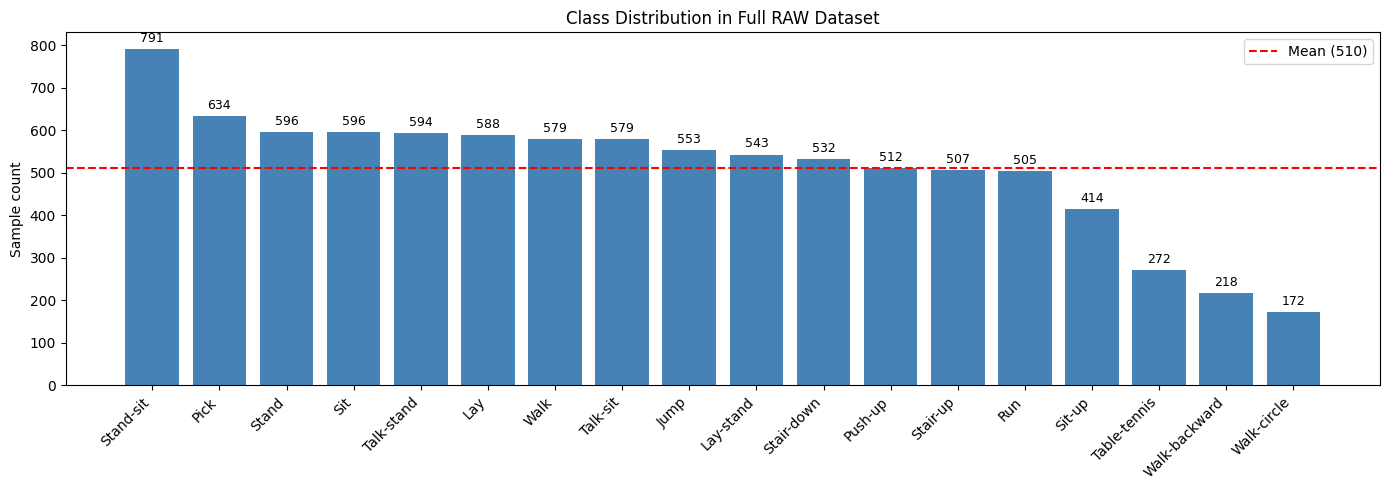

Most frequent:  Stand-sit — 791 samples
Least frequent: Walk-circle — 172 samples
Imbalance ratio: 4.6x


In [6]:
import matplotlib.pyplot as plt
import numpy as np

counts = np.bincount(Y_RAW)
order = np.argsort(counts)[::-1]

plt.figure(figsize=(14, 5))
bars = plt.bar(range(num_classes), counts[order], color='steelblue')
plt.xticks(range(num_classes), [labels_raw[i] for i in order], rotation=45, ha='right')
plt.axhline(counts.mean(), color='red', linestyle='--', label=f'Mean ({counts.mean():.0f})')
plt.bar_label(bars, padding=3, fontsize=9)
plt.title('Class Distribution in Full RAW Dataset')
plt.ylabel('Sample count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Most frequent:  {labels_raw[counts.argmax()]} — {counts.max()} samples")
print(f"Least frequent: {labels_raw[counts.argmin()]} — {counts.min()} samples")
print(f"Imbalance ratio: {counts.max() / counts.min():.1f}x")

In [8]:
model = prepare_model(labels=labels_raw, scaler=SCALER_RAW)

history, total_time = model.fit(
    x_train=X_raw_train,
    y_train=Y_raw_train,
    x_val=X_raw_val,
    y_val=Y_raw_val,
    epochs=150,
    batch_size=256,
    verbose=2,
    mask=lengths_raw_train,
    val_mask=lengths_raw_val,
    lr_decay_epochs=30,
    lr_decay=0.75,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-3,
)

model.save(r"models\har_model_raw_v0.nnp")

Epoch 1/150, 2.92s/epoch - ETA: 00:07:17
Loss: 2.420547, Acc: 0.2747
Val Loss: 1.654103 - Val Acc: 0.4709
Epoch 3/150, 2.75s/epoch - ETA: 00:06:54
Loss: 1.238664, Acc: 0.5834
Val Loss: 1.036167 - Val Acc: 0.7006
Epoch 5/150, 2.73s/epoch - ETA: 00:06:45
Loss: 0.870248, Acc: 0.6953
Val Loss: 0.776574 - Val Acc: 0.7643
Epoch 7/150, 2.74s/epoch - ETA: 00:06:37
Loss: 0.652442, Acc: 0.7743
Val Loss: 0.609971 - Val Acc: 0.7784
Epoch 9/150, 2.74s/epoch - ETA: 00:06:30
Loss: 0.529320, Acc: 0.8087
Val Loss: 0.591482 - Val Acc: 0.7616
Epoch 11/150, 2.73s/epoch - ETA: 00:06:24
Loss: 0.457426, Acc: 0.8294
Val Loss: 0.530410 - Val Acc: 0.7953
Epoch 13/150, 2.74s/epoch - ETA: 00:06:18
Loss: 0.402004, Acc: 0.8487
Val Loss: 0.496202 - Val Acc: 0.8095
Epoch 15/150, 2.74s/epoch - ETA: 00:06:12
Loss: 0.355916, Acc: 0.8632
Val Loss: 0.478354 - Val Acc: 0.8122
Epoch 17/150, 2.73s/epoch - ETA: 00:06:06
Loss: 0.335480, Acc: 0.8686
Val Loss: 0.445983 - Val Acc: 0.8171
Epoch 19/150, 2.74s/epoch - ETA: 00:06:00


In [9]:
print(f"Total training time: {total_time:.2f} seconds")
for metric_name, values in history.metrics.items():
    print(f"{metric_name}: {values}")

Total training time: 382.26 seconds
train_loss: [2.420546770095825, 1.5682876110076904, 1.2386637926101685, 1.0210877656936646, 0.8702483773231506, 0.744455099105835, 0.6524417400360107, 0.5854073166847229, 0.5293195247650146, 0.48708757758140564, 0.4574258029460907, 0.4286773204803467, 0.40200427174568176, 0.37957504391670227, 0.3559163808822632, 0.3483678102493286, 0.335480272769928, 0.33137619495391846, 0.3169739544391632, 0.31530267000198364, 0.30008795857429504, 0.2995486855506897, 0.2849864363670349, 0.28627458214759827, 0.27882981300354004, 0.27204030752182007, 0.27294158935546875, 0.2690925598144531, 0.2664016783237457, 0.2561701834201813, 0.25073114037513733, 0.2511536180973053, 0.24643336236476898, 0.2429405003786087, 0.2399642914533615, 0.24272441864013672, 0.2319040447473526, 0.22701531648635864, 0.22361469268798828, 0.22131788730621338, 0.21938584744930267, 0.2165767401456833, 0.2140168994665146, 0.2106131762266159, 0.20643773674964905, 0.20162199437618256, 0.2126111984252

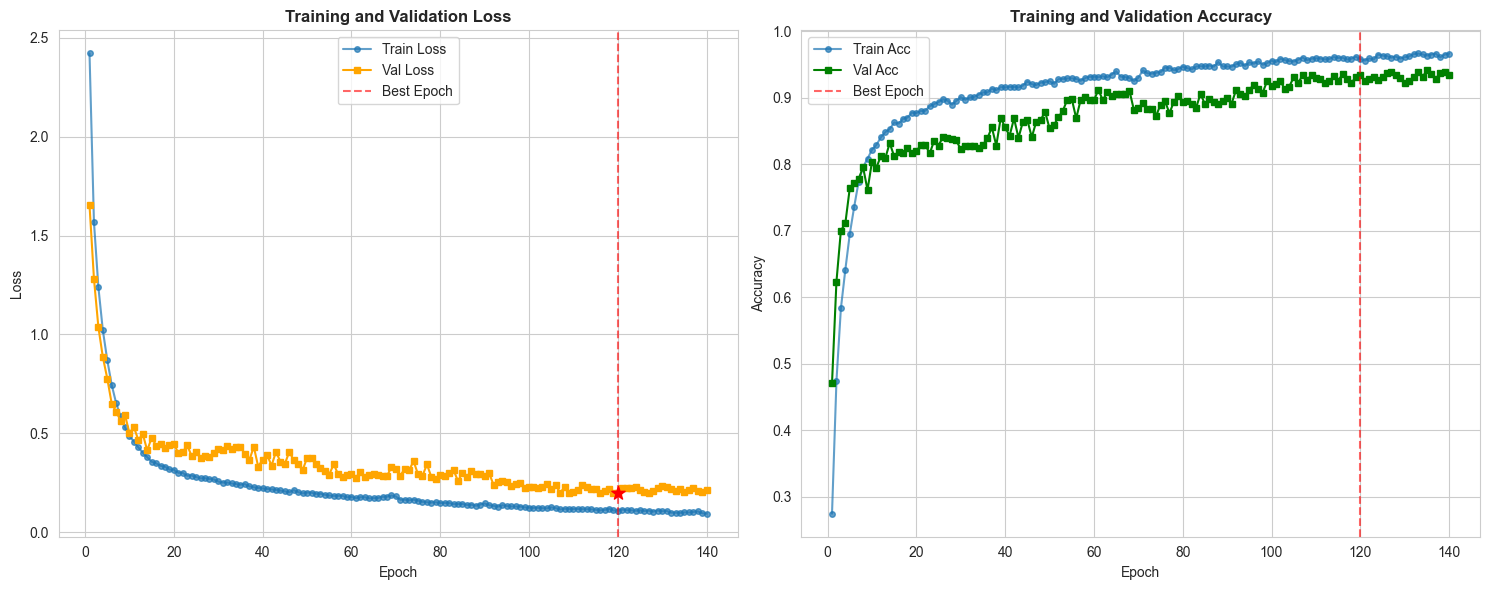

In [10]:
plot_training_history(history)

## 1.1 Evaluation

### 1.1.1 Confisuion matrix

In [6]:
model: Sequential = Network.load(r"models\har_model_raw_v0.nnp")

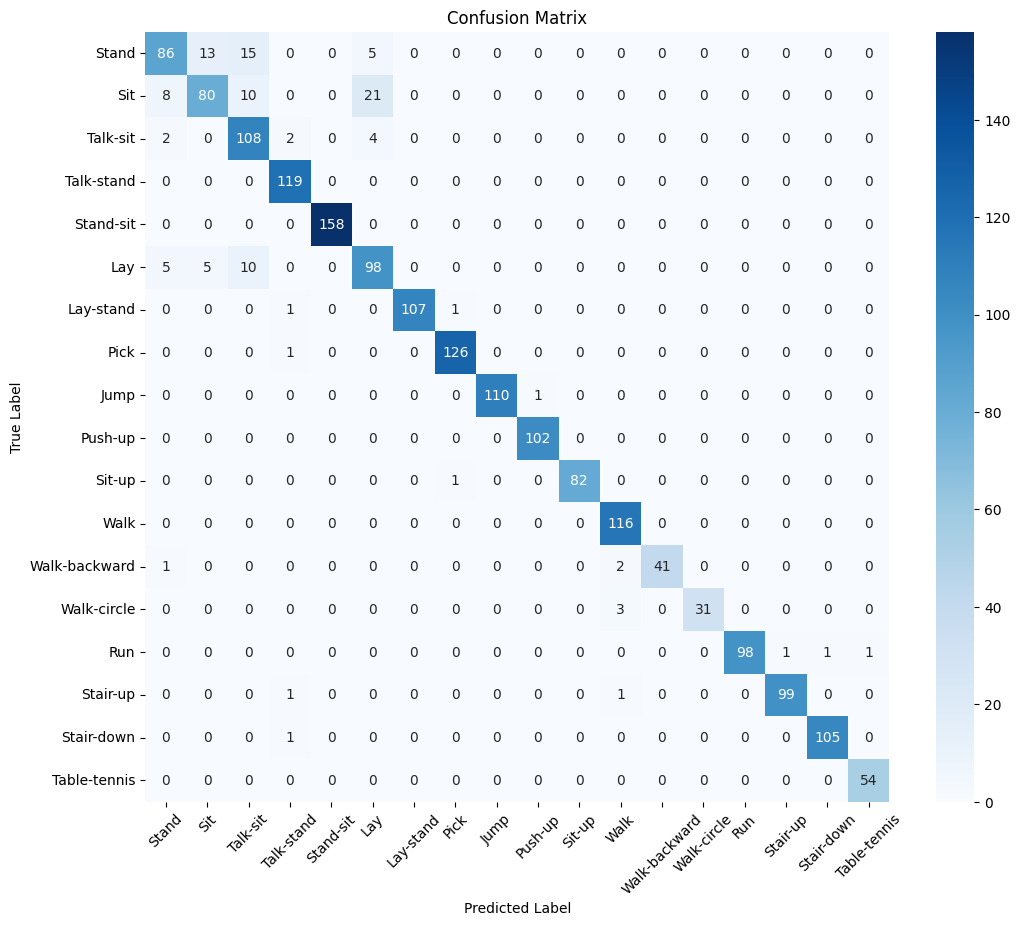

In [7]:
_preds_raw = model.predict(X_raw_test, mask=lengths_raw_test)
y_raw_true_idx = np.argmax(Y_raw_test, axis=1)
y_raw_pred_idx = np.argmax(_preds_raw, axis=1)
plot_confusion_matrix(y_raw_true_idx, y_raw_pred_idx, model, lengths_test=lengths_raw_test, activity_map=model.activity_labels)

### 1.1.2 Metrics per activity

In [8]:
predictions = model.predict(X_raw_test, mask=lengths_raw_test)
global_m, class_df = get_detailed_metrics(Y_raw_test, predictions, activity_map)

In [9]:
print(class_df)

               precision    recall  f1-score     support
Stand           0.843137  0.722689  0.778281  119.000000
Sit             0.816327  0.672269  0.737327  119.000000
Talk-sit        0.755245  0.931034  0.833977  116.000000
Talk-stand      0.952000  1.000000  0.975410  119.000000
Stand-sit       1.000000  1.000000  1.000000  158.000000
Lay             0.765625  0.830508  0.796748  118.000000
Lay-stand       1.000000  0.981651  0.990741  109.000000
Pick            0.984375  0.992126  0.988235  127.000000
Jump            1.000000  0.990991  0.995475  111.000000
Push-up         0.990291  1.000000  0.995122  102.000000
Sit-up          1.000000  0.987952  0.993939   83.000000
Walk            0.950820  1.000000  0.974790  116.000000
Walk-backward   1.000000  0.931818  0.964706   44.000000
Walk-circle     1.000000  0.911765  0.953846   34.000000
Run             1.000000  0.970297  0.984925  101.000000
Stair-up        0.990000  0.980198  0.985075  101.000000
Stair-down      0.990566  0.990

### 1.1.2.1 F1-score

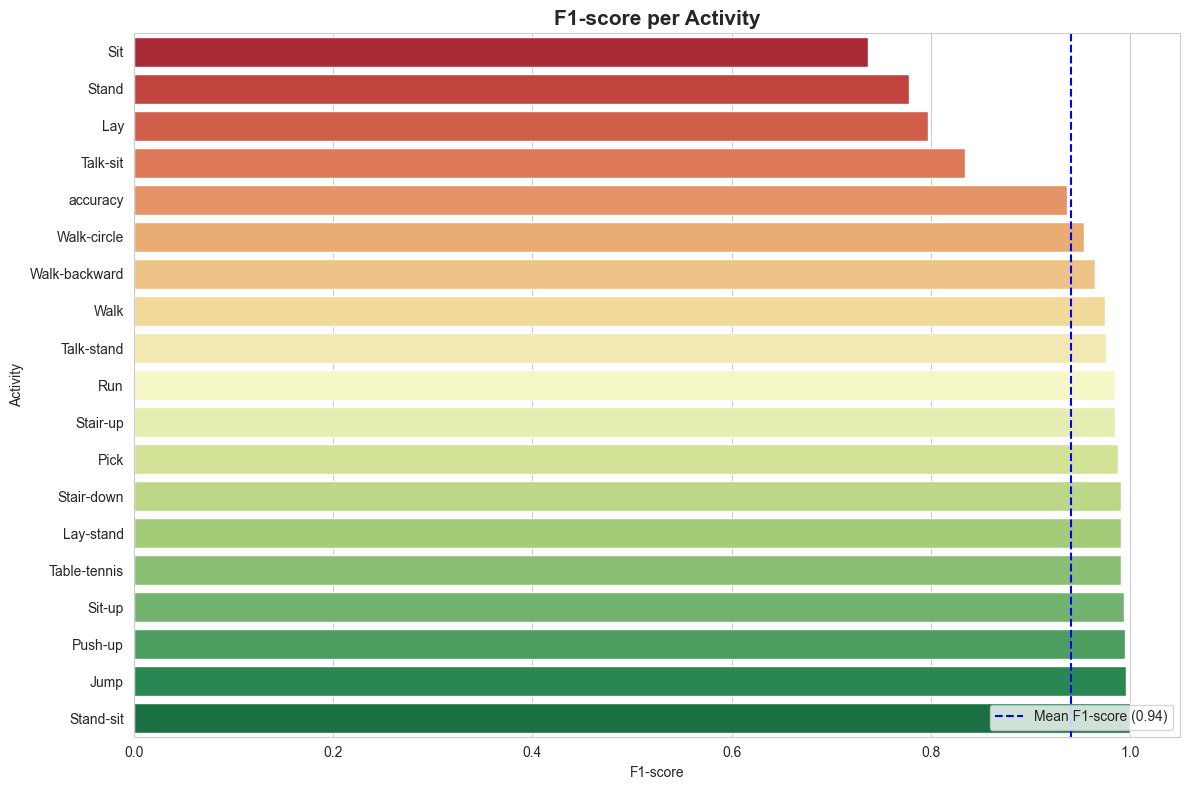

In [14]:
plot_class_performance(class_df, metric="f1-score")

### 1.1.2.2 Recall

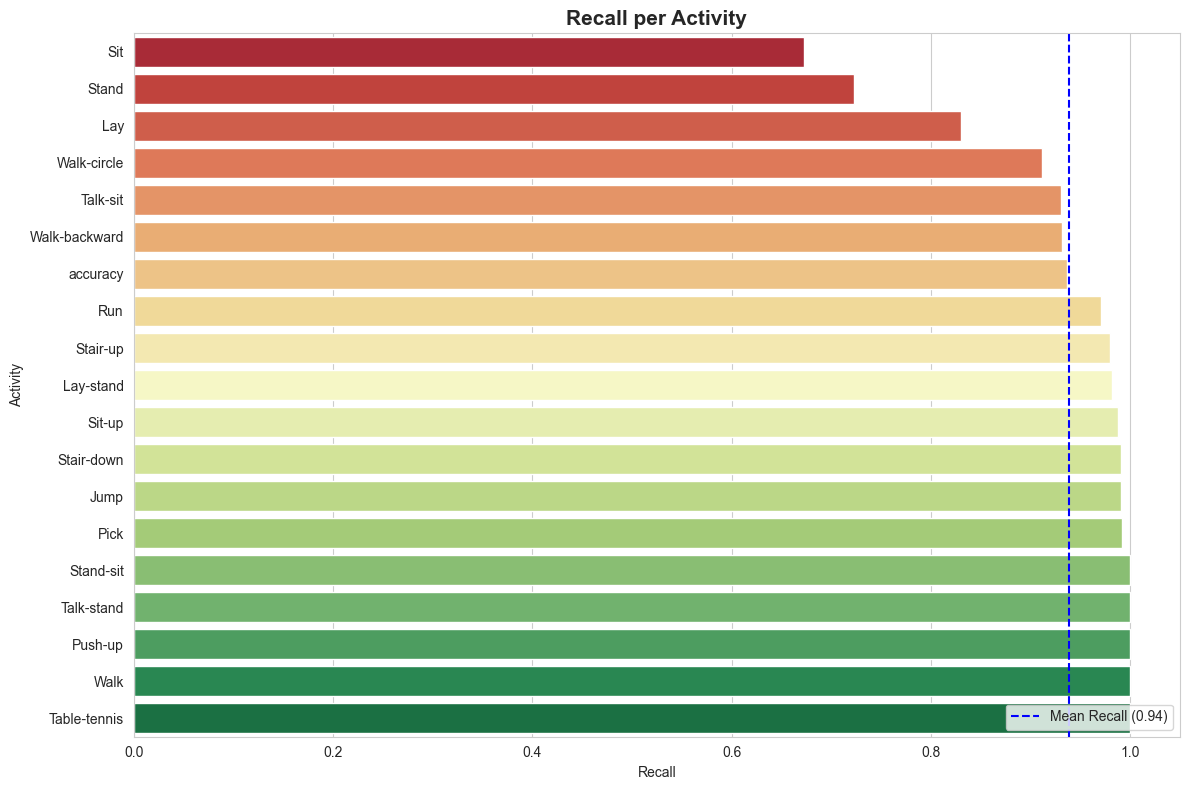

In [15]:
plot_class_performance(class_df, metric="recall")

### 1.1.2.3 Precision

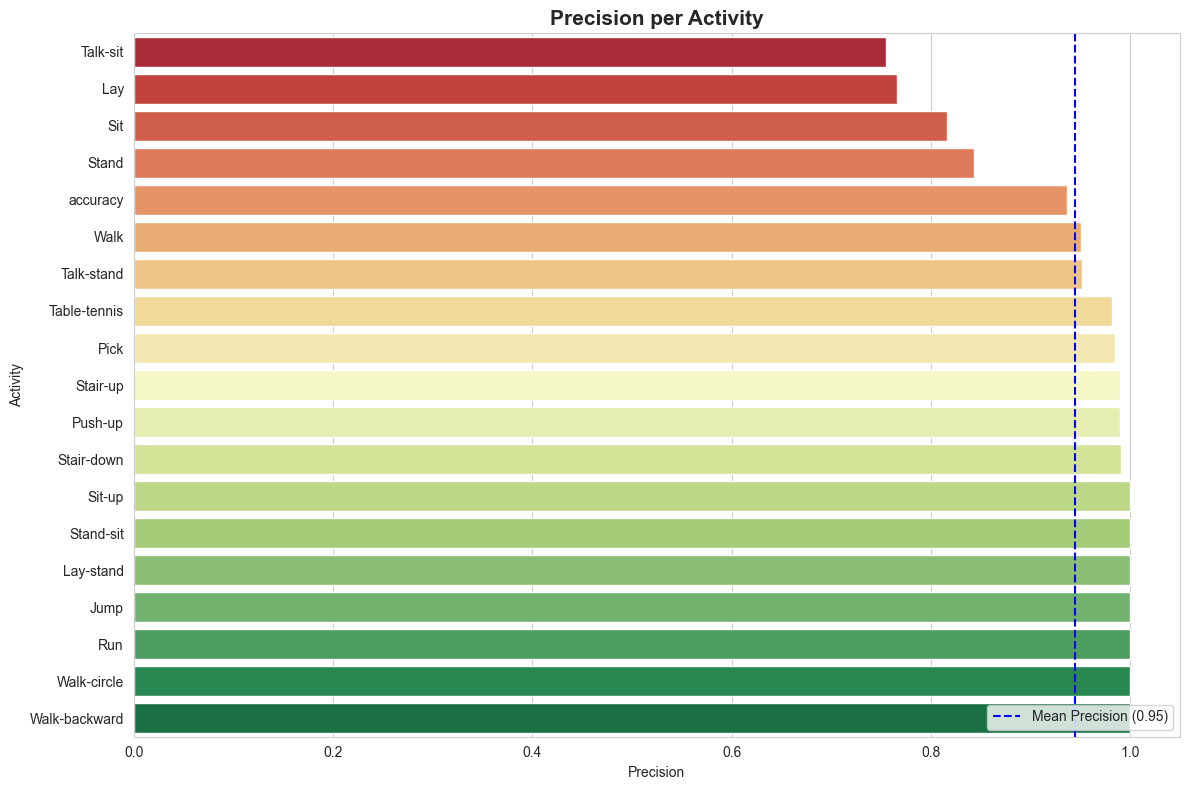

In [16]:
plot_class_performance(class_df, metric="precision")

### 1.1.2.4 Top confused classes by total misses

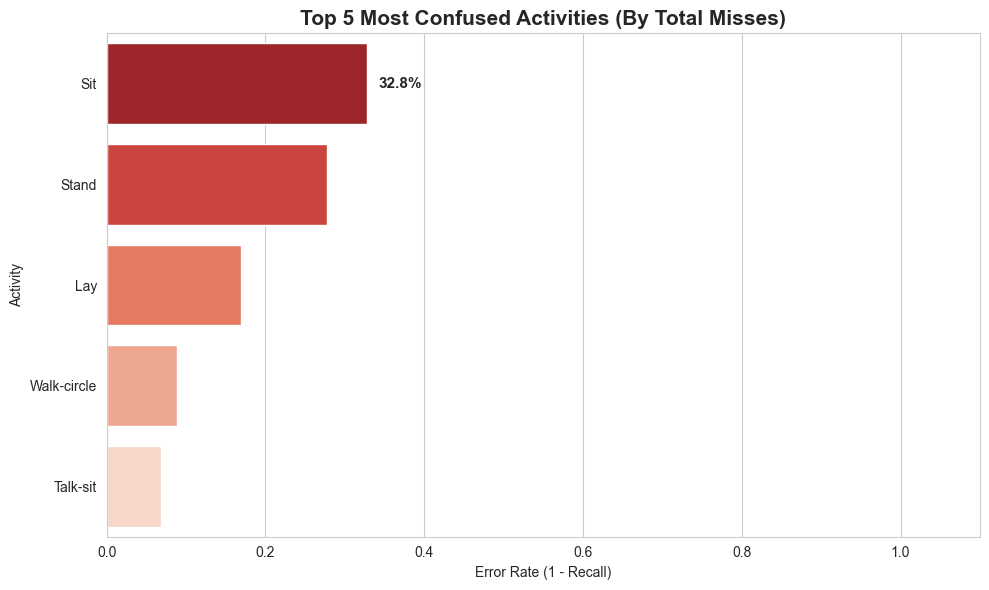

In [17]:
plot_most_confused_classes(class_df, top_n=5)

### 1.1.2.5 Top mutually confused classes

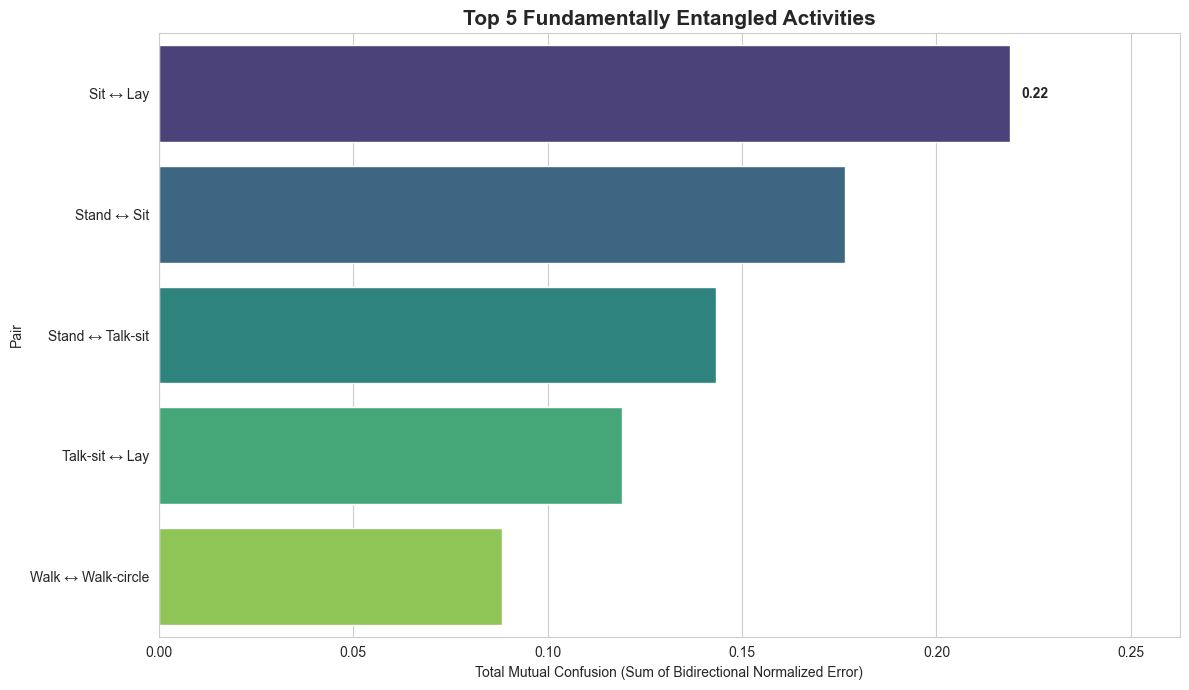

In [18]:
plot_top_mutual_confusions(Y_raw_test, predictions, activity_map, top_n=5)

# 2. Neural network evaluation with the original 18 classes (magnitude)

In [5]:
X_MAGNITUDE, Y_MAGNITUDE, LENGHTS_MAGNITUDE, SCALER_MAGNITUDE = prepare_har_dataset(
    dataset_path, mode="mag", shuffle=False, random_state=42
)

In [6]:
_X_tmp, X_magnitude_test, _Y_tmp, Y_magnitude_test_int, _len_tmp, lengths_magnitude_test = train_test_split(
    X_MAGNITUDE, Y_MAGNITUDE, LENGHTS_MAGNITUDE, test_size=0.2, random_state=42, stratify=Y_MAGNITUDE
)
X_magnitude_train, X_magnitude_val, Y_magnitude_train_int, Y_magnitude_val_int, lengths_magnitude_train, lengths_magnitude_val = train_test_split(
    _X_tmp, _Y_tmp, _len_tmp, test_size=0.25, random_state=42, stratify=_Y_tmp
)
del _X_tmp, _Y_tmp, _len_tmp

labels_magnitude = [activity_map[i] for i in range(num_classes)]
Y_magnitude_train = np.eye(num_classes)[Y_magnitude_train_int.astype(int)]
Y_magnitude_val   = np.eye(num_classes)[Y_magnitude_val_int.astype(int)]
Y_magnitude_test  = np.eye(num_classes)[Y_magnitude_test_int.astype(int)]

print(f"Magnitude split  →  Train: {X_magnitude_train.shape[0]}  Val: {X_magnitude_val.shape[0]}  Test: {X_magnitude_test.shape[0]}")
print(f"Class balance (train): {np.bincount(Y_magnitude_train_int)}")

Magnitude split  →  Train: 5511  Val: 1837  Test: 1837
Class balance (train): [358 358 347 356 475 353 325 380 332 308 248 347 130 104 303 305 319 163]


In [7]:
model_mag = prepare_model(labels=labels_magnitude, scaler=SCALER_MAGNITUDE)

history_mag, total_time = model_mag.fit(
    x_train=X_magnitude_train,
    y_train=Y_magnitude_train,
    x_val=X_magnitude_val,
    y_val=Y_magnitude_val,
    epochs=150,
    batch_size=256,
    verbose=2,
    mask=lengths_magnitude_train,
    val_mask=lengths_magnitude_val,
    lr_decay_epochs=30,
    lr_decay=0.75,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-3,
)

model_mag.save(r"models\har_model_magnitude_v0.nnp")

Epoch 1/150, 3.00s/epoch - ETA: 00:07:30
Loss: 2.331955, Acc: 0.2562
Val Loss: 1.802018 - Val Acc: 0.3718
Epoch 3/150, 2.42s/epoch - ETA: 00:06:26
Loss: 1.544649, Acc: 0.4513
Val Loss: 1.311619 - Val Acc: 0.5280
Epoch 5/150, 2.41s/epoch - ETA: 00:06:09
Loss: 1.299580, Acc: 0.5328
Val Loss: 1.134662 - Val Acc: 0.5672
Epoch 7/150, 2.40s/epoch - ETA: 00:05:59
Loss: 1.126545, Acc: 0.5883
Val Loss: 0.940725 - Val Acc: 0.6434
Epoch 9/150, 2.38s/epoch - ETA: 00:05:50
Loss: 0.985074, Acc: 0.6289
Val Loss: 0.849291 - Val Acc: 0.6690
Epoch 11/150, 2.40s/epoch - ETA: 00:05:43
Loss: 0.880050, Acc: 0.6652
Val Loss: 0.771798 - Val Acc: 0.6962
Epoch 13/150, 2.38s/epoch - ETA: 00:05:37
Loss: 0.787537, Acc: 0.6993
Val Loss: 0.717891 - Val Acc: 0.7142
Epoch 15/150, 2.40s/epoch - ETA: 00:05:31
Loss: 0.729498, Acc: 0.7131
Val Loss: 0.665517 - Val Acc: 0.7284
Epoch 17/150, 2.37s/epoch - ETA: 00:05:25
Loss: 0.667806, Acc: 0.7385
Val Loss: 0.691449 - Val Acc: 0.7011
Epoch 19/150, 2.40s/epoch - ETA: 00:05:20


In [8]:
print(f"Total training time: {total_time:.2f} seconds")
for metric_name, values in history_mag.metrics.items():
    print(f"{metric_name}: {values}")

Total training time: 257.36 seconds
train_loss: [2.3319551944732666, 1.7832956314086914, 1.544649362564087, 1.4074268341064453, 1.2995802164077759, 1.207489013671875, 1.1265449523925781, 1.0507543087005615, 0.9850742220878601, 0.9174232482910156, 0.8800495862960815, 0.8205121159553528, 0.7875372171401978, 0.7535530924797058, 0.7294979095458984, 0.6759710907936096, 0.6678062081336975, 0.6424450278282166, 0.6036996841430664, 0.6019255518913269, 0.5699154138565063, 0.5529732704162598, 0.548224687576294, 0.5371739864349365, 0.4993803799152374, 0.4750328063964844, 0.4757266938686371, 0.4589387774467468, 0.45521023869514465, 0.44589558243751526, 0.43804001808166504, 0.42002397775650024, 0.415749728679657, 0.41063112020492554, 0.4034885764122009, 0.4001884460449219, 0.41287294030189514, 0.38911718130111694, 0.3945905566215515, 0.38953888416290283, 0.3849779963493347, 0.3758280575275421, 0.3798963129520416, 0.3641093075275421, 0.3713638186454773, 0.3602716624736786, 0.36186346411705017, 0.3561

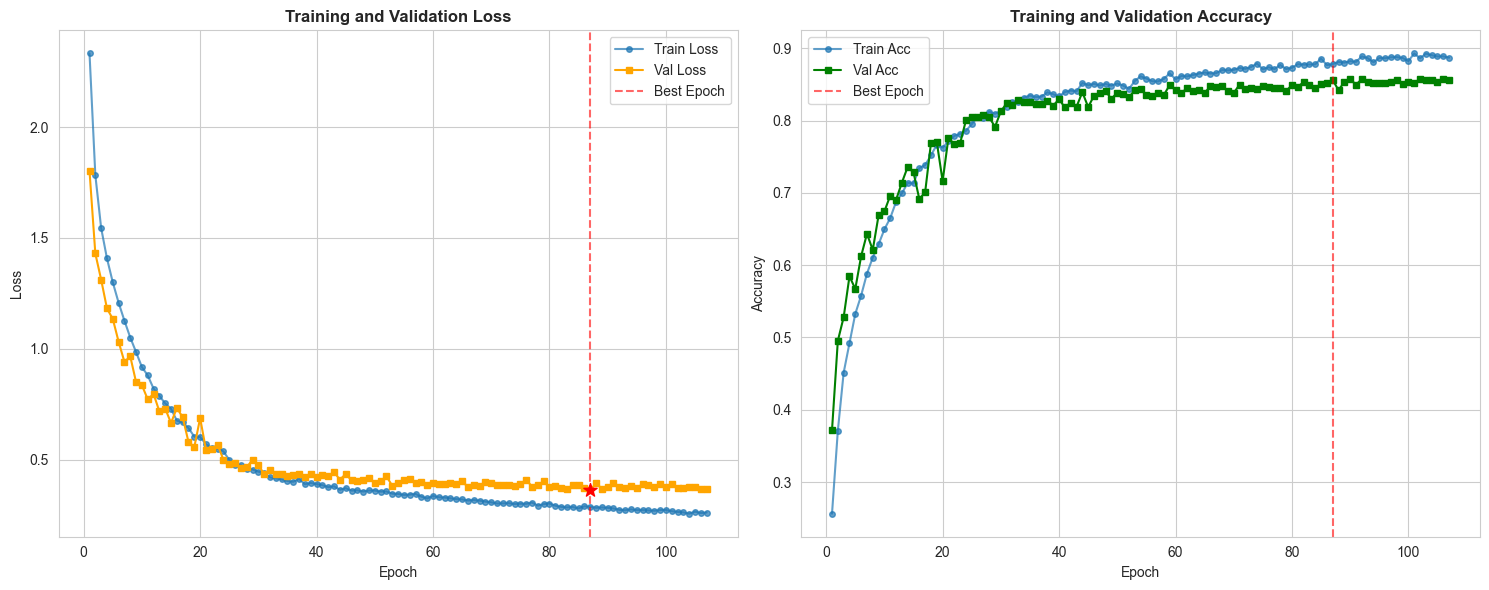

In [9]:
plot_training_history(history_mag)

## 2.1 Evaluation

In [10]:
model_mag = Network.load(r"models\har_model_magnitude_v0.nnp")

### 2.1.1 Confisuion matrix

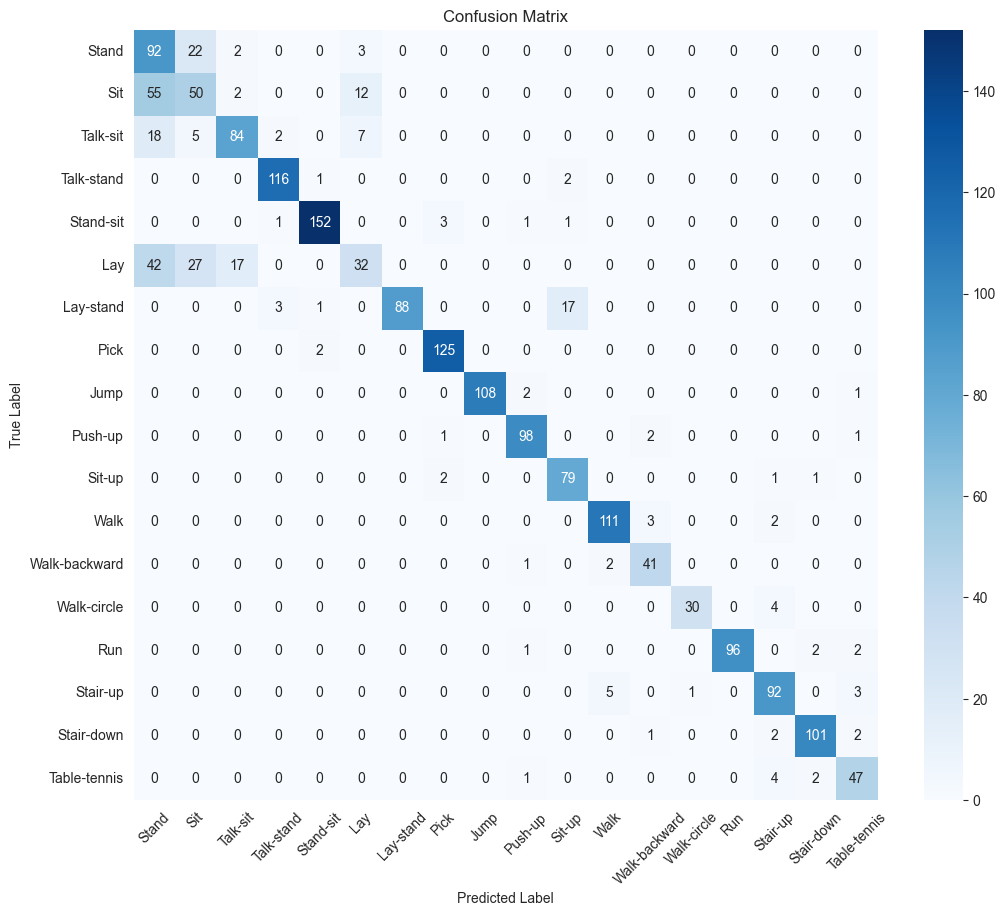

In [11]:
_preds_mag = model_mag.predict(X_magnitude_test, mask=lengths_magnitude_test)
y_mag_true_idx = np.argmax(Y_magnitude_test, axis=1)
y_mag_pred_idx = np.argmax(_preds_mag, axis=1)
plot_confusion_matrix(
    y_mag_true_idx,
    y_mag_pred_idx,
    model_mag,
    lengths_test=lengths_magnitude_test,
    activity_map=model_mag.activity_labels,
)

### 2.1.2 Metrics per activity

In [12]:
predictions = model_mag.predict(X_magnitude_test, mask=lengths_magnitude_test)
global_m, class_df = get_detailed_metrics(Y_magnitude_test, predictions, activity_map=model_mag.activity_labels)

In [14]:
print(class_df)

               precision    recall  f1-score     support
Stand           0.444444  0.773109  0.564417  119.000000
Sit             0.480769  0.420168  0.448430  119.000000
Talk-sit        0.800000  0.724138  0.760181  116.000000
Talk-stand      0.950820  0.974790  0.962656  119.000000
Stand-sit       0.974359  0.962025  0.968153  158.000000
Lay             0.592593  0.271186  0.372093  118.000000
Lay-stand       1.000000  0.807339  0.893401  109.000000
Pick            0.954198  0.984252  0.968992  127.000000
Jump            1.000000  0.972973  0.986301  111.000000
Push-up         0.942308  0.960784  0.951456  102.000000
Sit-up          0.797980  0.951807  0.868132   83.000000
Walk            0.940678  0.956897  0.948718  116.000000
Walk-backward   0.872340  0.931818  0.901099   44.000000
Walk-circle     0.967742  0.882353  0.923077   34.000000
Run             1.000000  0.950495  0.974619  101.000000
Stair-up        0.876190  0.910891  0.893204  101.000000
Stair-down      0.952830  0.952

### 2.1.2.1 F1-score

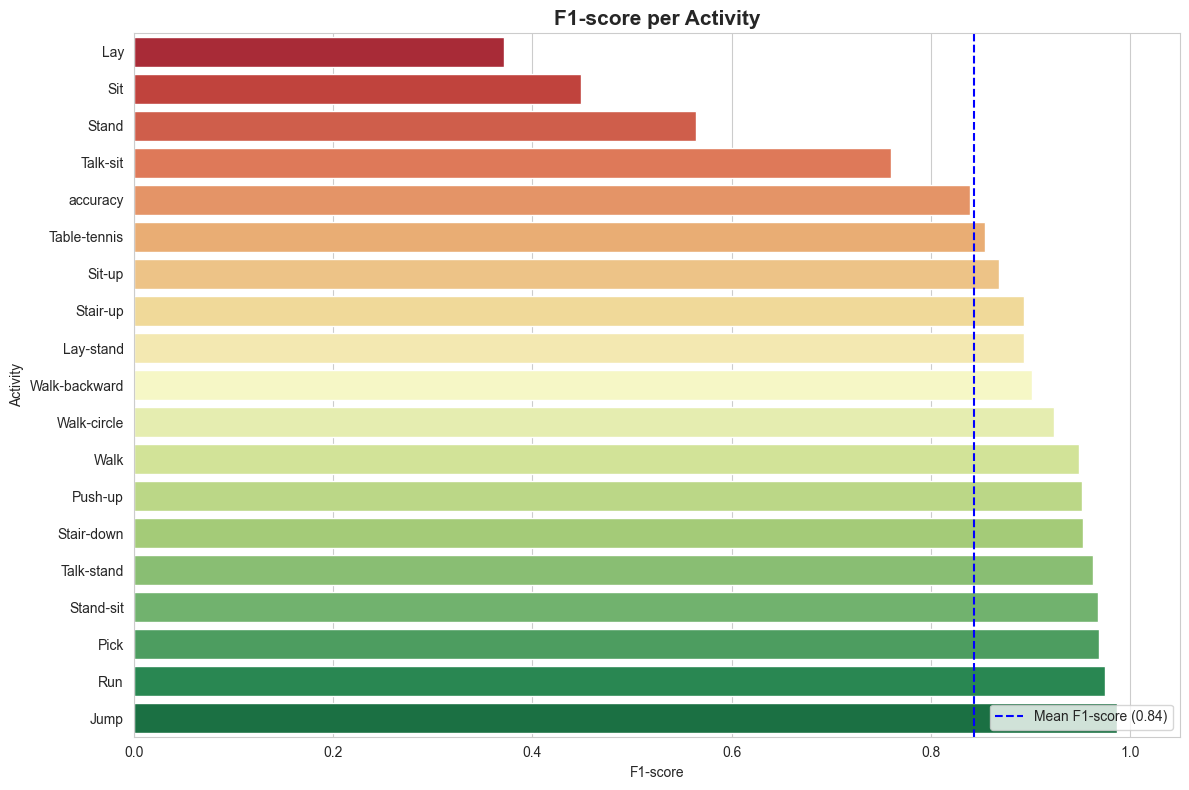

In [15]:
plot_class_performance(class_df, metric="f1-score")

### 2.1.2.2 Recall

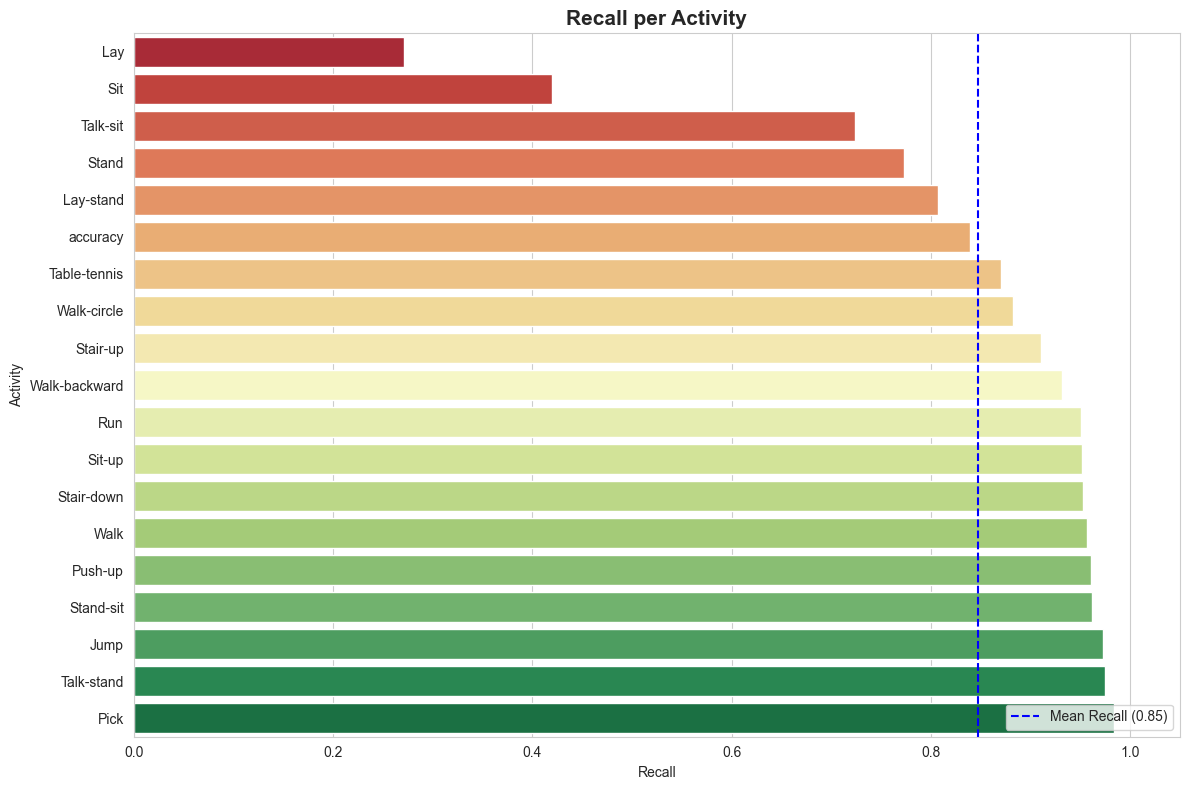

In [16]:
plot_class_performance(class_df, metric="recall")

### 2.1.2.3 Precision

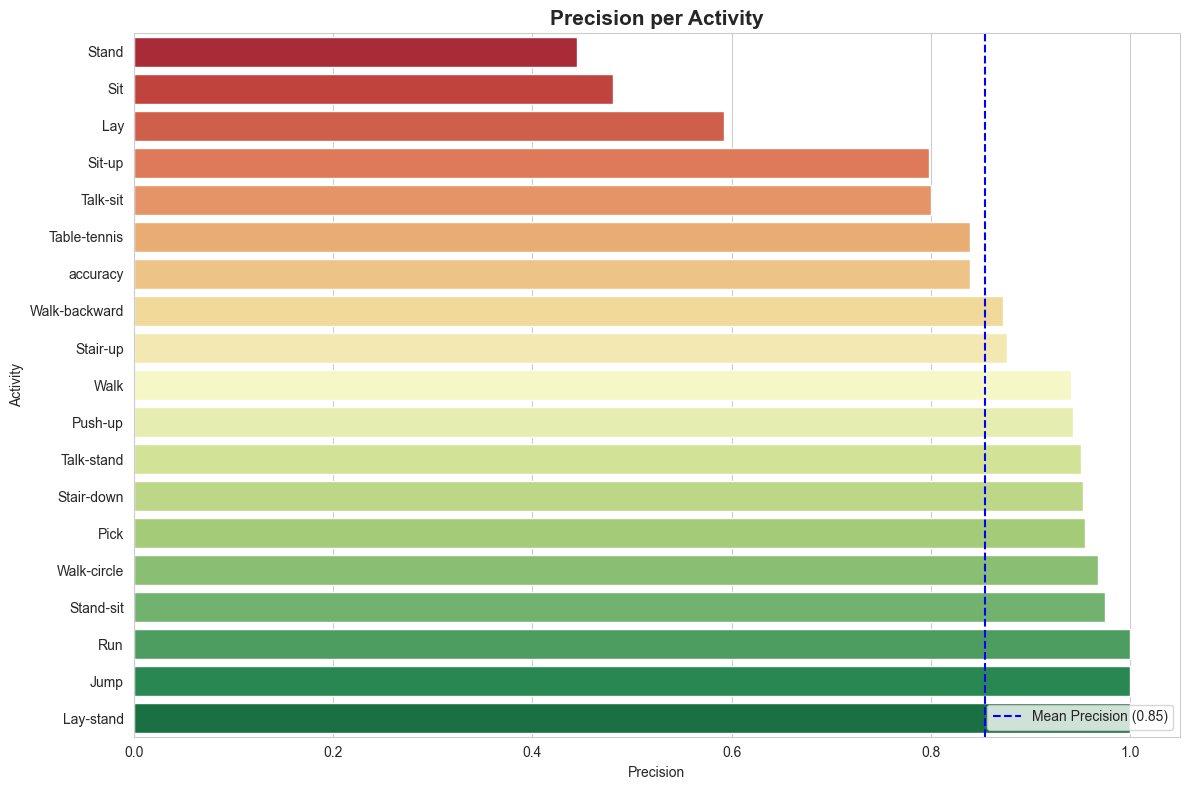

In [17]:
plot_class_performance(class_df, metric="precision")

### 2.1.2.4 Most confused classes by total misses

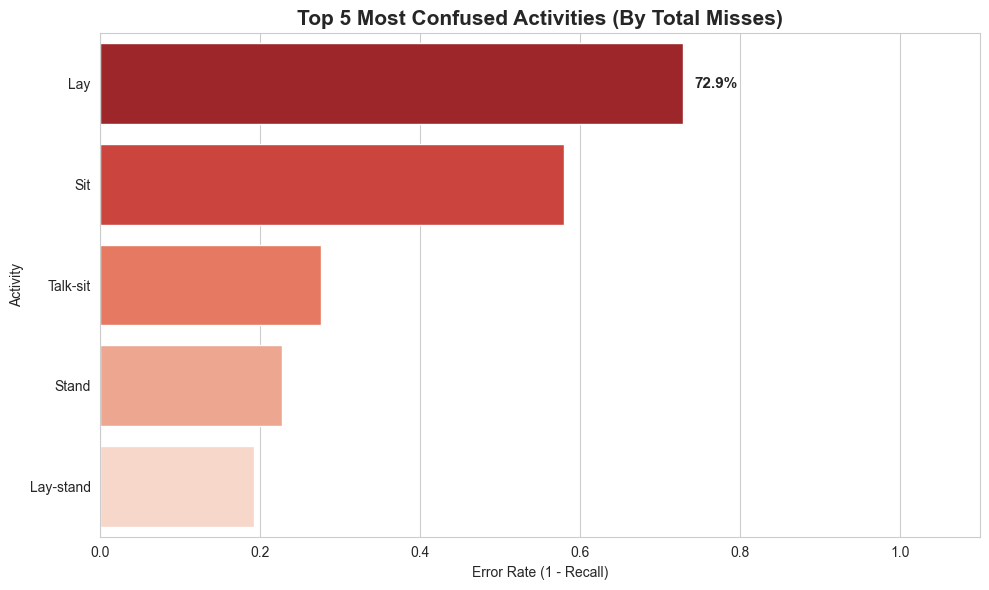

In [18]:
plot_most_confused_classes(class_df, top_n=5)

### 2.1.2.5 Top mutually confused classes

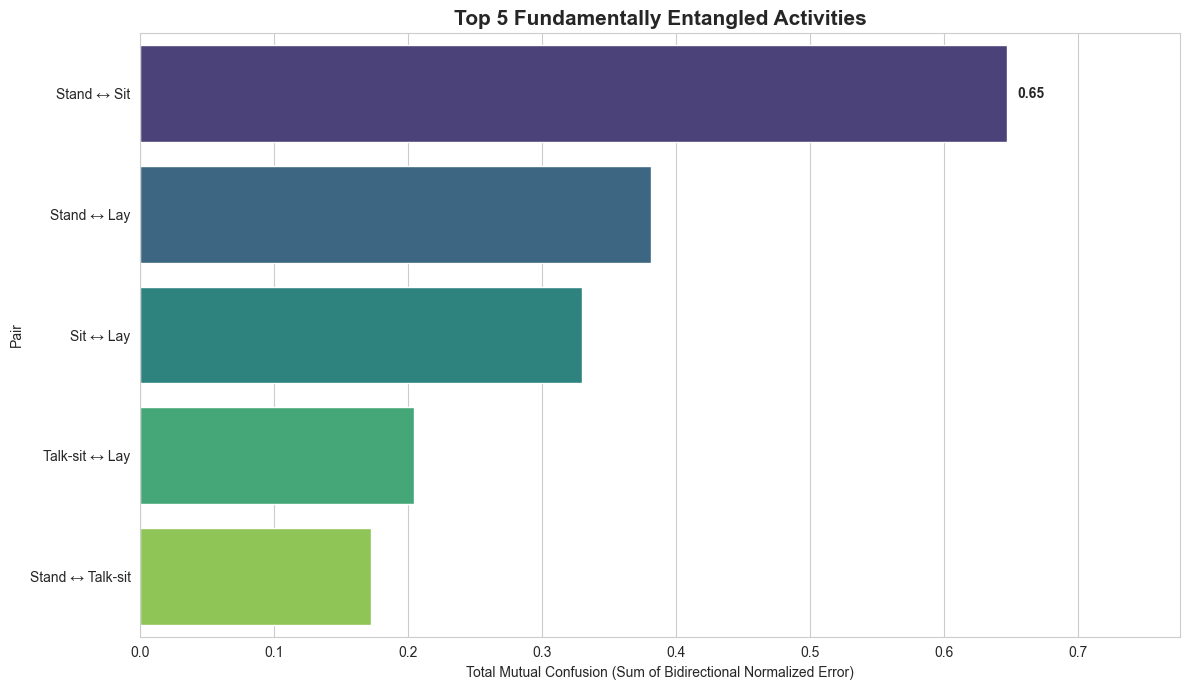

In [19]:
plot_top_mutual_confusions(Y_magnitude_test, predictions, activity_map, top_n=5)

# 3. Neural network evaluation (hybrid)

In [5]:
X_HYBRID, Y_HYBRID, LENGHTS_HYBRID, SCALER_HYBRID = prepare_har_dataset(
    dataset_path, mode="hybrid", shuffle=False, random_state=42
)

In [6]:
_X_tmp, X_hybrid_test, _Y_tmp, Y_hybrid_test_int, _len_tmp, lengths_hybrid_test = train_test_split(
    X_HYBRID, Y_HYBRID, LENGHTS_HYBRID, test_size=0.2, random_state=42, stratify=Y_HYBRID
)
X_hybrid_train, X_hybrid_val, Y_hybrid_train_int, Y_hybrid_val_int, lengths_hybrid_train, lengths_hybrid_val = train_test_split(
    _X_tmp, _Y_tmp, _len_tmp, test_size=0.25, random_state=42, stratify=_Y_tmp
)
del _X_tmp, _Y_tmp, _len_tmp

labels_hybrid = [activity_map[i] for i in range(num_classes)]
Y_hybrid_train = np.eye(num_classes)[Y_hybrid_train_int.astype(int)]
Y_hybrid_val   = np.eye(num_classes)[Y_hybrid_val_int.astype(int)]
Y_hybrid_test  = np.eye(num_classes)[Y_hybrid_test_int.astype(int)]

print(f"Hybrid split  →  Train: {X_hybrid_train.shape[0]}  Val: {X_hybrid_val.shape[0]}  Test: {X_hybrid_test.shape[0]}")
print(f"Class balance (train): {np.bincount(Y_hybrid_train_int)}")

Hybrid split  →  Train: 5511  Val: 1837  Test: 1837
Class balance (train): [358 358 347 356 475 353 325 380 332 308 248 347 130 104 303 305 319 163]


In [7]:
model_hybrid = prepare_model(labels=labels_hybrid, scaler=SCALER_HYBRID)

history_hybrid, total_time = model_hybrid.fit(
    x_train=X_hybrid_train,
    y_train=Y_hybrid_train,
    x_val=X_hybrid_val,
    y_val=Y_hybrid_val,
    epochs=150,
    batch_size=128,
    verbose=2,
    mask=lengths_hybrid_train,
    val_mask=lengths_hybrid_val,
    lr_decay_epochs=30,
    lr_decay=0.75,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-3,
)

model_hybrid.save(r"models\har_model_hybrid_v0.nnp")

Epoch 1/150, 3.34s/epoch - ETA: 00:08:19
Loss: 2.134889, Acc: 0.3277
Val Loss: 1.386992 - Val Acc: 0.5514
Epoch 3/150, 2.81s/epoch - ETA: 00:07:21
Loss: 1.005373, Acc: 0.6364
Val Loss: 0.775824 - Val Acc: 0.7485
Epoch 5/150, 2.83s/epoch - ETA: 00:07:05
Loss: 0.757791, Acc: 0.7313
Val Loss: 0.622365 - Val Acc: 0.7964
Epoch 7/150, 2.82s/epoch - ETA: 00:06:55
Loss: 0.595634, Acc: 0.7786
Val Loss: 0.563015 - Val Acc: 0.7893
Epoch 9/150, 2.84s/epoch - ETA: 00:06:48
Loss: 0.512369, Acc: 0.8068
Val Loss: 0.485255 - Val Acc: 0.8116
Epoch 11/150, 2.83s/epoch - ETA: 00:06:40
Loss: 0.441951, Acc: 0.8244
Val Loss: 0.451326 - Val Acc: 0.7991
Epoch 13/150, 2.82s/epoch - ETA: 00:06:34
Loss: 0.410175, Acc: 0.8351
Val Loss: 0.391868 - Val Acc: 0.8492
Epoch 15/150, 2.81s/epoch - ETA: 00:06:27
Loss: 0.355503, Acc: 0.8583
Val Loss: 0.368393 - Val Acc: 0.8459
Epoch 17/150, 2.82s/epoch - ETA: 00:06:20
Loss: 0.341590, Acc: 0.8550
Val Loss: 0.359145 - Val Acc: 0.8645
Epoch 19/150, 2.81s/epoch - ETA: 00:06:14


In [8]:
print(f"Total training time: {total_time:.2f} seconds")
for metric_name, values in history_hybrid.metrics.items():
    print(f"{metric_name}: {values}")

Total training time: 359.33 seconds
train_loss: [2.1348893642425537, 1.3094003200531006, 1.0053731203079224, 0.840607225894928, 0.7577908635139465, 0.6593098640441895, 0.5956340432167053, 0.5448830127716064, 0.5123692750930786, 0.4932876229286194, 0.44195109605789185, 0.41883233189582825, 0.41017475724220276, 0.38010892271995544, 0.35550275444984436, 0.3348816931247711, 0.34159013628959656, 0.32256200909614563, 0.3079536557197571, 0.3082222044467926, 0.29061561822891235, 0.2886444926261902, 0.2677859961986542, 0.278362512588501, 0.2613098919391632, 0.2662273943424225, 0.2765563130378723, 0.2574712336063385, 0.24791911244392395, 0.23931768536567688, 0.22077693045139313, 0.2165829986333847, 0.2147437185049057, 0.20404714345932007, 0.19957461953163147, 0.19937068223953247, 0.1944408118724823, 0.19698825478553772, 0.1917569935321808, 0.1892615407705307, 0.18442367017269135, 0.18554741144180298, 0.17705002427101135, 0.18050605058670044, 0.17874136567115784, 0.16771894693374634, 0.1636859923

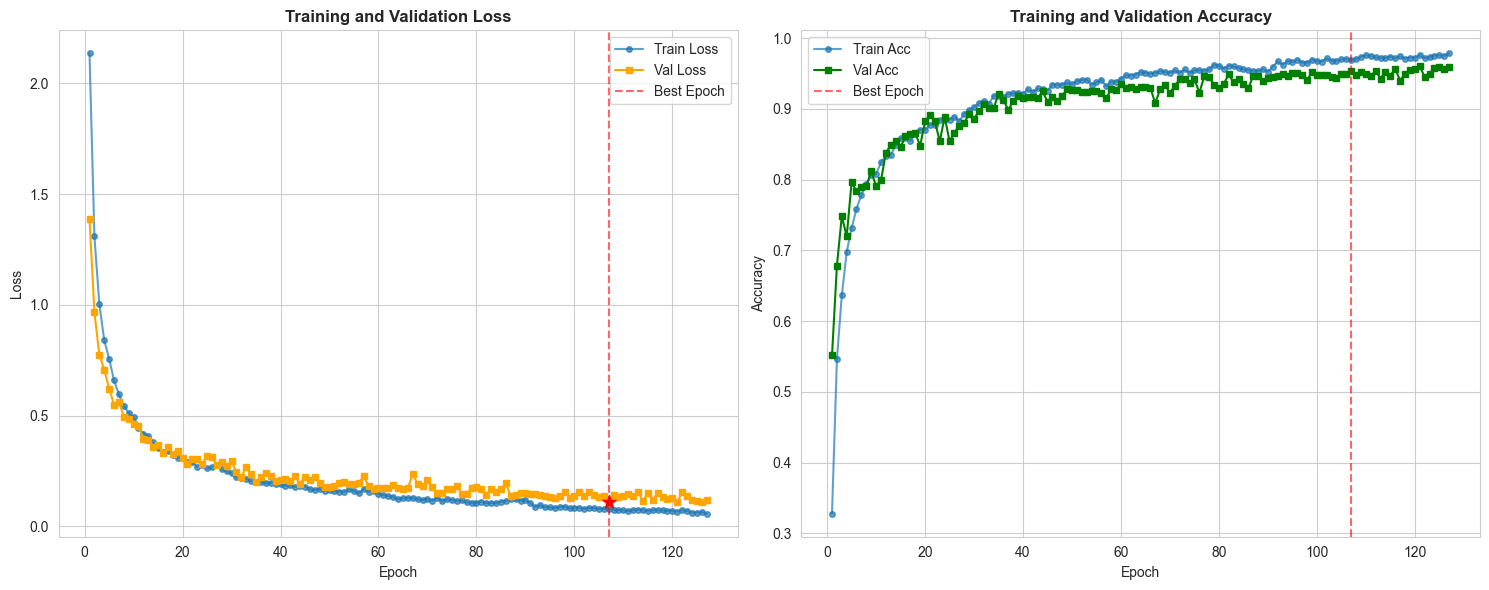

In [9]:
plot_training_history(history_hybrid)

## 3.1 Evaluation

### 3.1.1 Confisuion matrix

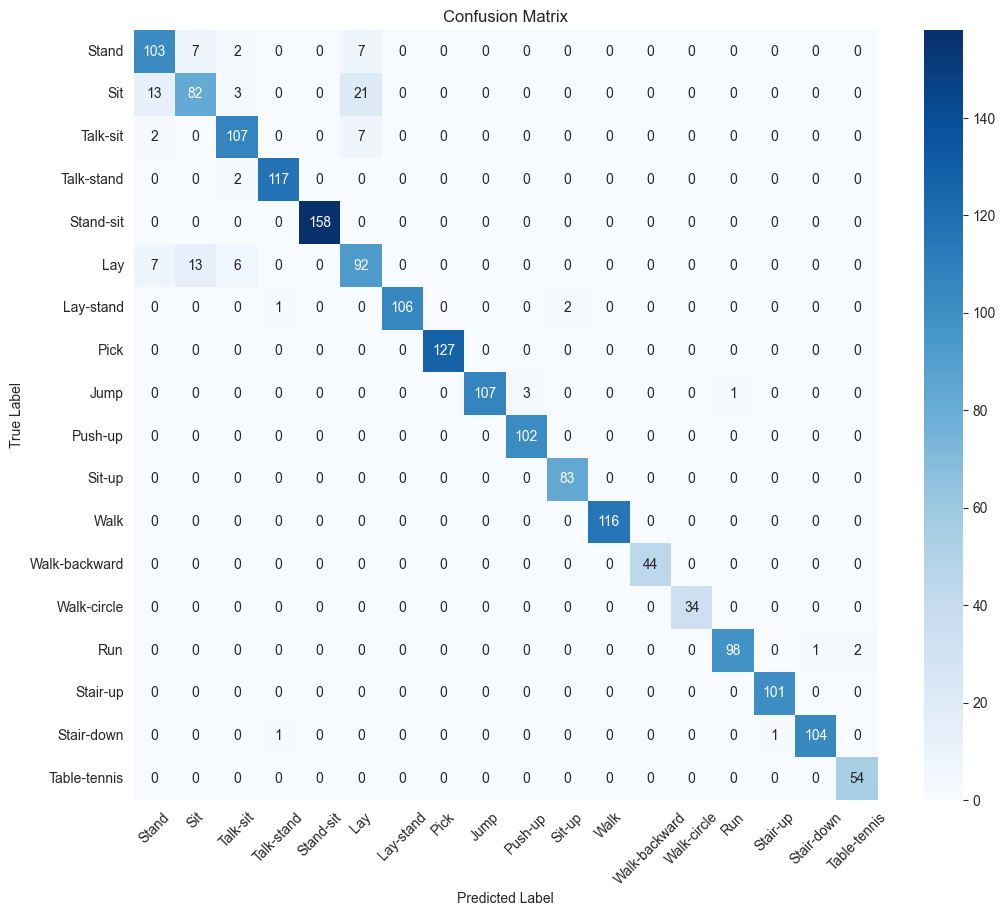

In [10]:
_preds_hybrid = model_hybrid.predict(X_hybrid_test, mask=lengths_hybrid_test)
y_hybrid_true_idx = np.argmax(Y_hybrid_test, axis=1)
y_hybrid_pred_idx = np.argmax(_preds_hybrid, axis=1)
plot_confusion_matrix(
    y_hybrid_true_idx,
    y_hybrid_pred_idx,
    model_hybrid,
    lengths_test=lengths_hybrid_test,
    activity_map=model_hybrid.activity_labels,
)

### 3.1.2 Metrics per activity

In [11]:
predictions_hybrid = model_hybrid.predict(X_hybrid_test, mask=lengths_hybrid_test)
global_m_hybrid, class_df_hybrid = get_detailed_metrics(Y_hybrid_test, predictions_hybrid, activity_map)

In [12]:
print(class_df_hybrid)

               precision    recall  f1-score     support
Stand           0.824000  0.865546  0.844262  119.000000
Sit             0.803922  0.689076  0.742081  119.000000
Talk-sit        0.891667  0.922414  0.906780  116.000000
Talk-stand      0.983193  0.983193  0.983193  119.000000
Stand-sit       1.000000  1.000000  1.000000  158.000000
Lay             0.724409  0.779661  0.751020  118.000000
Lay-stand       1.000000  0.972477  0.986047  109.000000
Pick            1.000000  1.000000  1.000000  127.000000
Jump            1.000000  0.963964  0.981651  111.000000
Push-up         0.971429  1.000000  0.985507  102.000000
Sit-up          0.976471  1.000000  0.988095   83.000000
Walk            1.000000  1.000000  1.000000  116.000000
Walk-backward   1.000000  1.000000  1.000000   44.000000
Walk-circle     1.000000  1.000000  1.000000   34.000000
Run             0.989899  0.970297  0.980000  101.000000
Stair-up        0.990196  1.000000  0.995074  101.000000
Stair-down      0.990476  0.981

### 3.1.2.1 F1-score

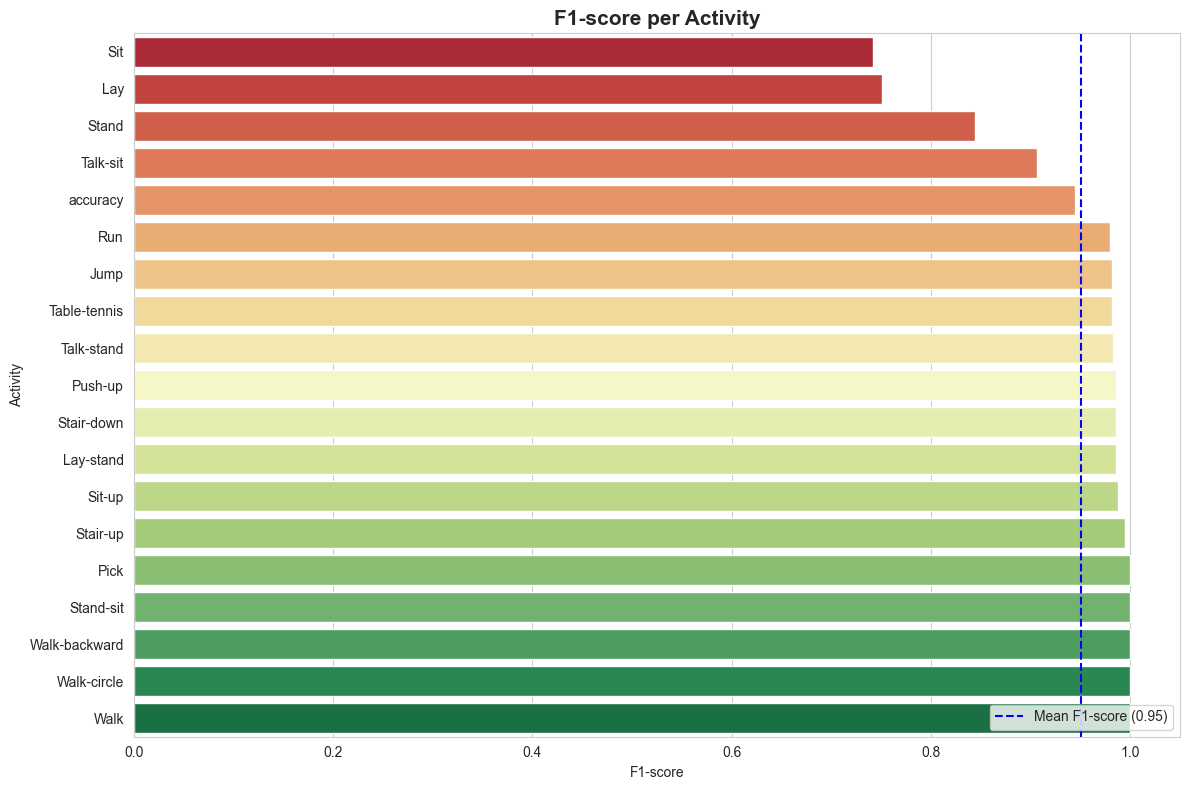

In [13]:
plot_class_performance(class_df_hybrid, metric="f1-score")

### 3.1.2.2 Recall

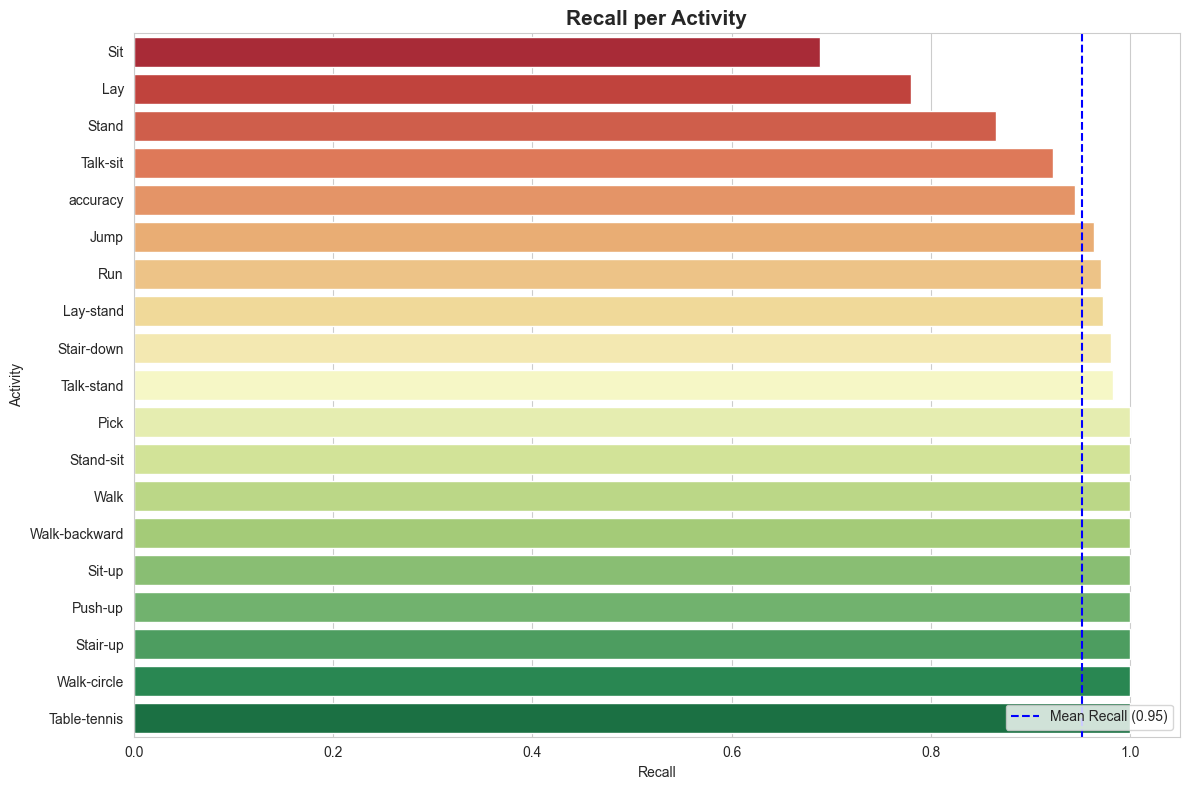

In [14]:
plot_class_performance(class_df_hybrid, metric="recall")

### 3.1.2.3 Precision

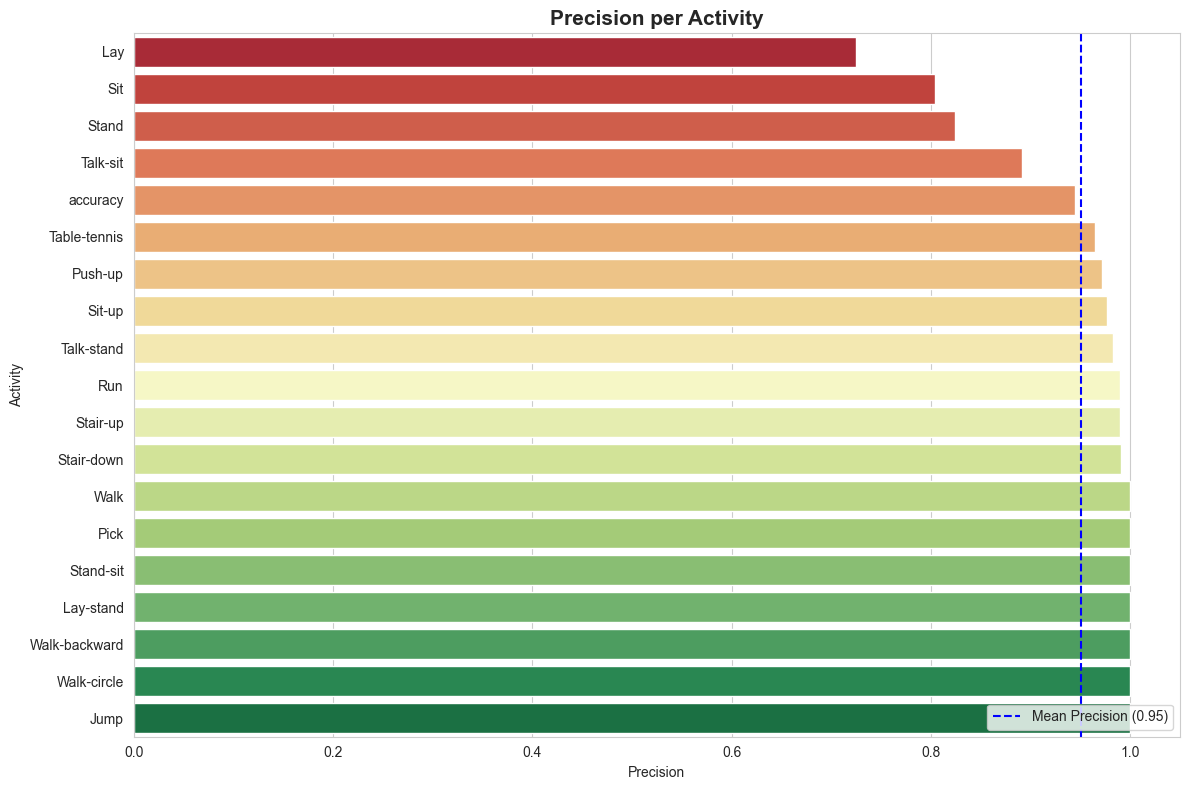

In [15]:
plot_class_performance(class_df_hybrid, metric="precision")

### 3.1.2.4 Most confused classes by total misses

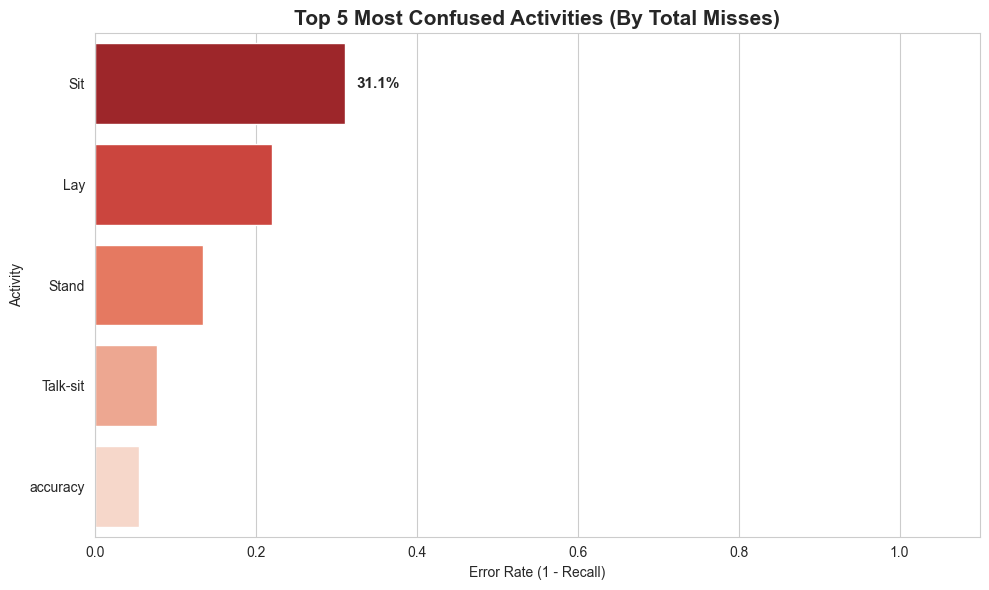

In [16]:
plot_most_confused_classes(class_df_hybrid, top_n=5)

### 3.1.2.5 Top mutually confused classes

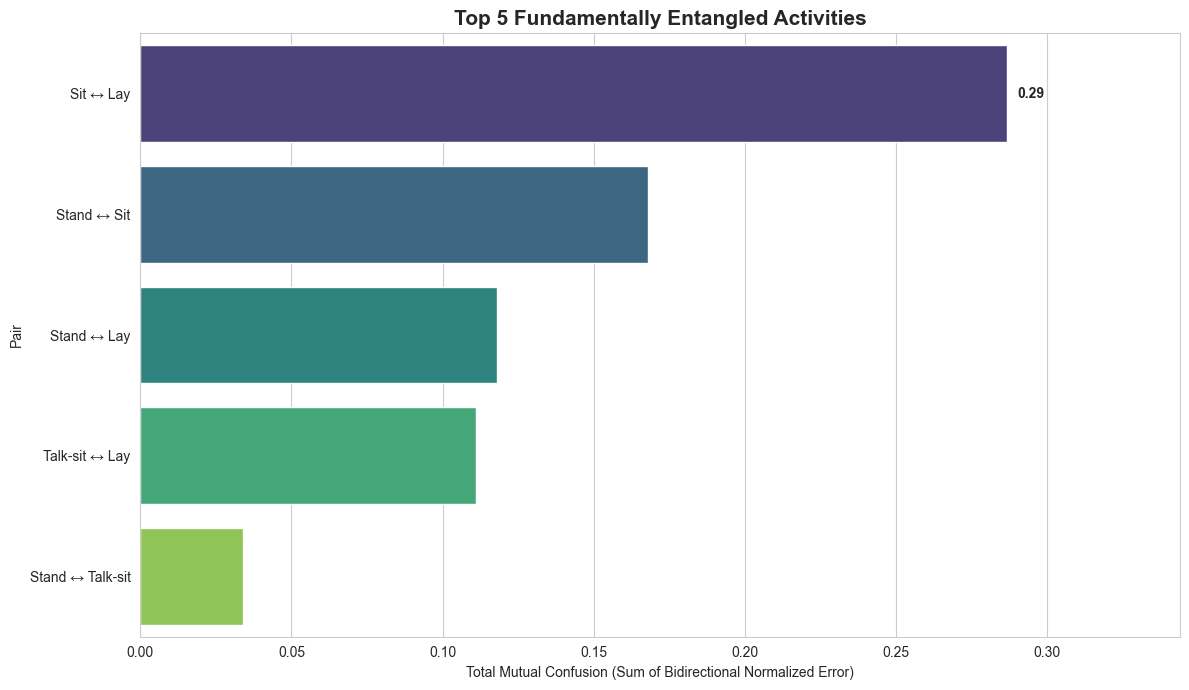

In [17]:
plot_top_mutual_confusions(Y_hybrid_test, predictions_hybrid, activity_map, top_n=5)

# 4. Comparsion of the three models - raw, magnitude, hybrid

In [18]:
model_raw: Sequential = Network.load(r"models\har_model_raw_v0.nnp")
model_mag: Sequential = Network.load(r"models\har_model_magnitude_v0.nnp")
model_hybrid: Sequential = Network.load(r"models\har_model_hybrid_v0.nnp")

In [19]:
X_raw, Y_raw, lengths_raw, _ = prepare_har_dataset(dataset_path, mode="raw", shuffle=False)
X_mag, Y_mag, lengths_mag, _ = prepare_har_dataset(dataset_path, mode="mag", shuffle=False)
X_hybrid, Y_hybrid, lengths_hybrid, _ = prepare_har_dataset(dataset_path, mode="hybrid", shuffle=False)

In [20]:
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw, lengths_train_raw, lengths_test_raw = train_test_split(
    X_raw, Y_raw, lengths_raw, test_size=0.2, random_state=2
)
X_train_mag, X_test_mag, Y_train_mag, Y_test_mag, lengths_train_mag, lengths_test_mag = train_test_split(
    X_mag, Y_mag, lengths_mag, test_size=0.2, random_state=2
)
X_train_hybrid, X_test_hybrid, Y_train_hybrid, Y_test_hybrid, lengths_train_hybrid, lengths_test_hybrid = (
    train_test_split(X_hybrid, Y_hybrid, lengths_hybrid, test_size=0.2, random_state=2)
)

In [21]:
Y_train_raw = to_one_hot(Y_train_raw, num_classes)
Y_test_raw = to_one_hot(Y_test_raw, num_classes)
Y_train_mag = to_one_hot(Y_train_mag, num_classes)
Y_test_mag = to_one_hot(Y_test_mag, num_classes)
Y_train_hybrid = to_one_hot(Y_train_hybrid, num_classes)
Y_test_hybrid = to_one_hot(Y_test_hybrid, num_classes)

In [22]:
def compare_models(model_list, test_data_list, activity_map):
    all_results = []
    class_comparison = []

    for (name, model), (x_t, y_t, l_t) in zip(model_list, test_data_list):
        print(f"Evaluating {name}...")
        preds = model.predict(x_t, mask=l_t)
        global_m, class_df = get_detailed_metrics(y_t, preds, activity_map)
        global_m["Model"] = name
        all_results.append(global_m)
        class_df["Model"] = name
        class_df["Activity"] = class_df.index
        class_comparison.append(class_df)
    report_df = pd.DataFrame(all_results).set_index("Model")
    comparison_df = pd.concat(class_comparison)
    return report_df, comparison_df


def plot_global_comparison(report_df):
    sns.set_style("whitegrid")
    plot_df = report_df.reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="viridis")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10, fontweight="bold")
    plt.title("Models Comparison: Raw vs. Magnitude vs. Hybrid", fontsize=15, fontweight="bold")
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_class_wise_comparison(class_comp_df, metric="f1-score"):
    plt.figure(figsize=(15, 8))
    order = class_comp_df.groupby("Activity")[metric].mean().sort_values(ascending=False).index
    sns.barplot(data=class_comp_df, x="Activity", y=metric, hue="Model", order=order, palette="muted")
    plt.title(f"Per-Activity {metric.upper()} Comparison", fontsize=16, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric.capitalize())
    plt.ylim(0, 1.1)
    plt.legend(title="Data Approach")
    plt.tight_layout()
    plt.show()

### 4.1 Metrics comparison

In [23]:
models = [("Raw", model_raw), ("Magnitude", model_mag), ("Hybrid", model_hybrid)]
test_sets = [
    (X_test_raw, Y_test_raw, lengths_test_raw),
    (X_test_mag, Y_test_mag, lengths_test_mag),
    (X_test_hybrid, Y_test_hybrid, lengths_test_hybrid),
]

report, class_comp = compare_models(models, test_sets, activity_map)

Evaluating Raw...
Evaluating Magnitude...
Evaluating Hybrid...


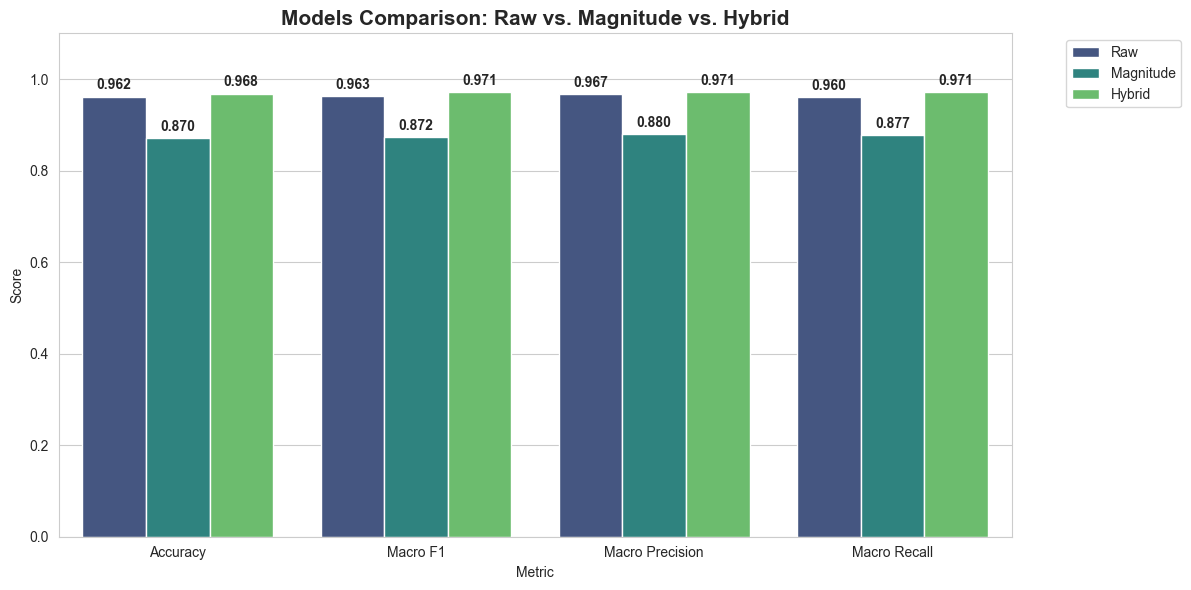

In [25]:
plot_global_comparison(report)

               precision    recall  f1-score     support      Model  \
Stand           0.909091  0.256410  0.400000  117.000000        Raw   
Sit             0.000000  0.000000  0.000000  101.000000        Raw   
Talk-sit        0.648515  0.992424  0.784431  132.000000        Raw   
Talk-stand      0.991150  1.000000  0.995556  112.000000        Raw   
Stand-sit       0.994565  1.000000  0.997275  183.000000        Raw   
Lay             0.441048  0.878261  0.587209  115.000000        Raw   
Lay-stand       1.000000  0.972222  0.985915  108.000000        Raw   
Pick            0.964286  1.000000  0.981818  108.000000        Raw   
Jump            1.000000  0.989899  0.994924   99.000000        Raw   
Push-up         0.990385  0.980952  0.985646  105.000000        Raw   
Sit-up          0.977778  0.988764  0.983240   89.000000        Raw   
Walk            0.981481  0.972477  0.976959  109.000000        Raw   
Walk-backward   0.958333  1.000000  0.978723   46.000000        Raw   
Walk-c

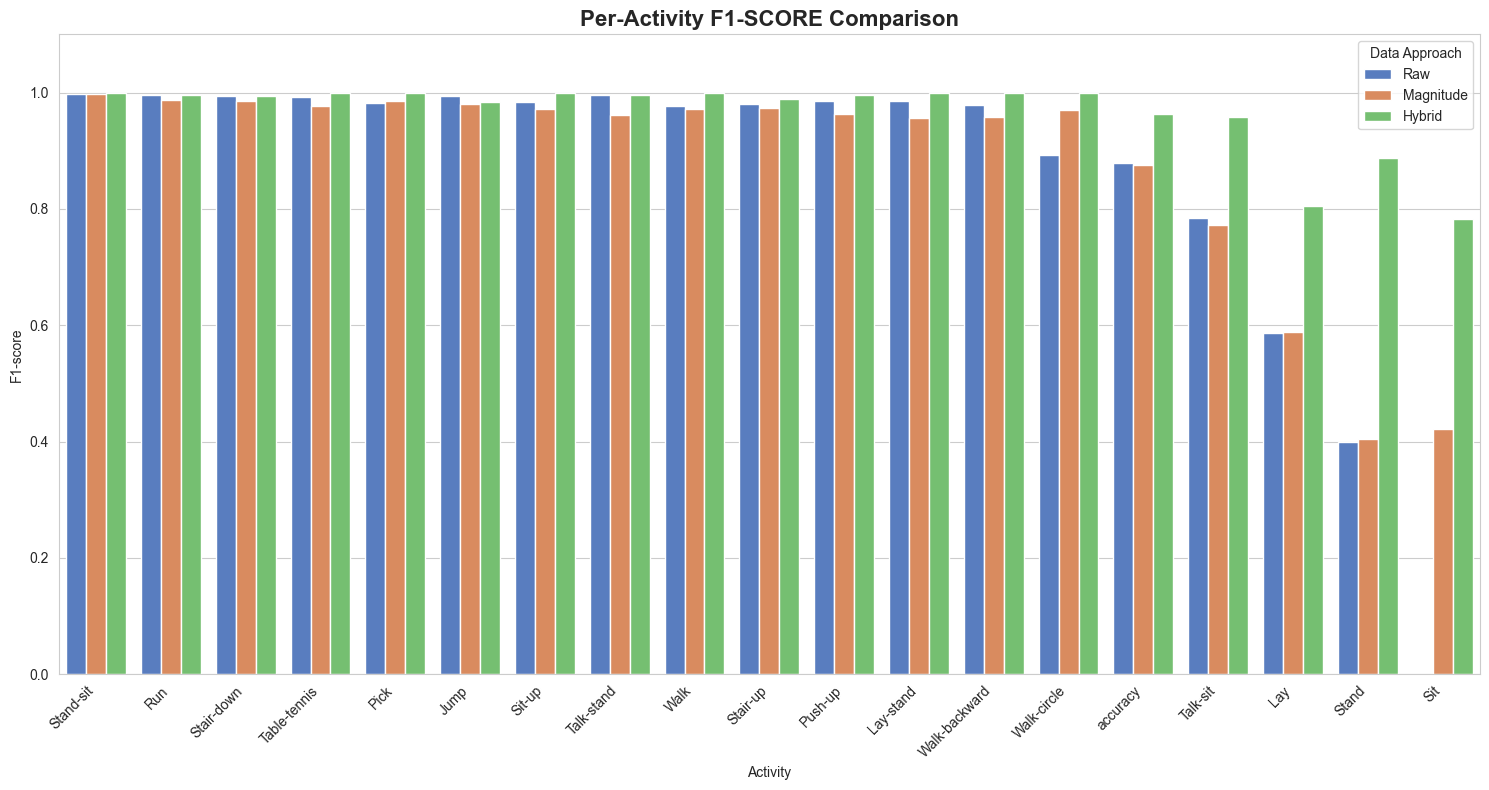

In [ ]:
print(class_comp)
plot_class_wise_comparison(class_comp, metric="f1-score")

# 5. Comparsion with PyTorch

In [5]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"CUDA version:    {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU Name:        {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu126
CUDA available:  True
CUDA version:    12.6
GPU Name:        NVIDIA GeForce GTX 1080


### But first we need to define the GlobalConcatPool layer which is not avaliable in PyTorch by default.

In [6]:
class TorchGlobalConcatPool(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.avg_pool = torch.nn.AdaptiveAvgPool1d(1)
        self.max_pool = torch.nn.AdaptiveMaxPool1d(1)

    def forward(self, x, lengths):
        time_steps = x.size(2)
        device = x.device
        mask = torch.arange(time_steps, device=device)[None, None, :] < lengths[:, None, None]
        x_masked = x * mask.float()
        avg_pool = torch.sum(x_masked, dim=2) / lengths[:, None]
        x_for_max = x.masked_fill(~mask, -1e9)
        max_pool = torch.max(x_for_max, dim=2)[0]
        return torch.cat([avg_pool, max_pool], dim=1)

In [7]:
from time import gmtime


class PytorchHARModel(torch.nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.layers = torch.nn.ModuleList(
            [
                torch.nn.Conv1d(in_channels, 32, kernel_size=31, stride=1, padding=15),
                torch.nn.BatchNorm1d(32),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv1d(32, 64, kernel_size=15, stride=2, padding=7),
                torch.nn.BatchNorm1d(64),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Dropout(0.2),
                torch.nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
                torch.nn.BatchNorm1d(128),
                torch.nn.ELU(),
                TorchGlobalConcatPool(),
                torch.nn.Linear(256, 128),
                torch.nn.BatchNorm1d(128),
                torch.nn.ELU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(128, num_classes),
                torch.nn.Softmax(dim=1),
            ]
        )
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)

    def forward(self, x, lengths=None):
        current_lengths = lengths
        for layer in self.layers:
            x = layer(x, current_lengths) if isinstance(layer, TorchGlobalConcatPool) else layer(x)
            if isinstance(layer, torch.nn.Conv1d) and current_lengths is not None:
                p = layer.padding[0]
                k = layer.kernel_size[0]
                s = layer.stride[0]
                current_lengths = torch.div(current_lengths + 2 * p - k, s, rounding_mode="floor") + 1  # type: ignore
        return x

    def _to_class_idx(self, y):
        """Convert one-hot or integer labels to a long tensor on self.device."""
        arr = np.argmax(y, axis=1) if len(y.shape) > 1 else y
        return torch.tensor(arr, dtype=torch.long).to(self.device)

    def fit(
        self,
        x_train,
        y_train,
        lengths_train,
        x_val=None,
        y_val=None,
        lengths_val=None,
        epochs=10,
        batch_size=64,
        verbose=1,
        early_stopping_patience=None,
        early_stopping_min_delta=0.0,
    ):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        criterion = torch.nn.NLLLoss()
        history = TrainingHistory()
        xt = torch.tensor(x_train, dtype=torch.float32).to(self.device)
        lt = torch.tensor(lengths_train, dtype=torch.float32).to(self.device)
        yt = self._to_class_idx(y_train)
        start_time = time()
        best_val_loss = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(epochs):
            self.train()
            epoch_loss = 0
            correct = 0
            indices = torch.randperm(xt.size(0))
            epoch_start_time = time()

            for start in range(0, xt.size(0), batch_size):
                optimizer.zero_grad()
                end = start + batch_size
                idx = indices[start:end]
                x_b, y_b, l_b = xt[idx], yt[idx], lt[idx]
                outputs = torch.log(self.forward(x_b, l_b) + 1e-10)
                loss = criterion(outputs, y_b)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                correct += (outputs.argmax(1) == y_b).sum().item()

            train_loss = epoch_loss / (xt.size(0) / batch_size)
            train_acc = correct / xt.size(0)
            epoch_duration = time() - epoch_start_time
            val_loss = None
            val_acc = None

            if x_val is not None and y_val is not None:
                self.eval()
                yv = self._to_class_idx(y_val)
                val_loss_sum = 0.0
                val_correct = 0
                val_total = 0
                for i in range(0, len(x_val), batch_size):
                    bx = torch.tensor(x_val[i : i + batch_size], dtype=torch.float32).to(self.device)
                    by = yv[i : i + batch_size]
                    bl = torch.tensor(
                        lengths_val[i : i + batch_size] if lengths_val is not None
                        else [x_val.shape[-1]] * bx.size(0),
                        dtype=torch.float32,
                    ).to(self.device)
                    with torch.no_grad():
                        out = torch.log(self.forward(bx, bl) + 1e-10)
                        loss_v = criterion(out, by)
                    val_loss_sum += loss_v.item() * by.size(0)
                    val_correct += (out.argmax(1) == by).sum().item()
                    val_total += by.size(0)
                val_loss = val_loss_sum / max(val_total, 1)
                val_acc = val_correct / max(val_total, 1)

                if early_stopping_patience is not None:
                    if best_val_loss is None or val_loss < best_val_loss - early_stopping_min_delta:
                        best_val_loss = val_loss
                        best_epoch = epoch
                        patience_counter = 0
                    else:
                        patience_counter += 1

            history.update(
                train_loss=train_loss,
                train_acc=train_acc,
                epoch_time=epoch_duration,
                lr=optimizer.param_groups[0]["lr"],
                val_loss=val_loss,
                val_acc=val_acc,
            )

            if verbose > 0 and (epoch % verbose == 0 or epoch == epochs - 1):
                message = (
                    f"Epoch {epoch + 1}/{epochs} - "
                    f"Loss: {train_loss:.6f}, Acc: {train_acc:.4f}, "
                    f"Time: {epoch_duration:.2f}s"
                )
                if val_loss is not None and val_acc is not None:
                    message += f", Val Loss: {val_loss:.6f}, Val Acc: {val_acc:.4f}"
                print(message)

            if (
                early_stopping_patience is not None
                and val_loss is not None
                and patience_counter >= early_stopping_patience
            ):
                if verbose > 0 and best_val_loss is not None:
                    print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.6f}).")
                break

        if best_epoch is not None:
            history.best_epoch = best_epoch
        return history, time() - start_time


In [ ]:
backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=1024 * 1024 * 1024 * 1024)

In [17]:
X_train_raw, X_val_raw, X_test_raw               = X_raw_train,     X_raw_val,     X_raw_test
Y_train_raw, Y_val_raw, Y_test_raw               = Y_raw_train,     Y_raw_val,     Y_raw_test
lengths_train_raw, lengths_val_raw, lengths_test_raw = lengths_raw_train, lengths_raw_val, lengths_raw_test

epochs                   = 150
batch_size               = 128
early_stopping_patience  = 20
early_stopping_min_delta = 1e-3

In [18]:
my_model = prepare_model(labels=labels_raw, scaler=SCALER_RAW)
pytorch_model = PytorchHARModel(in_channels=X_RAW.shape[1], num_classes=num_classes)

In [19]:
print("Training PyTorch model...")
history_pt, time_pt = pytorch_model.fit(
    X_train_raw, Y_train_raw, lengths_train_raw,
    x_val=X_val_raw,
    y_val=Y_val_raw,
    lengths_val=lengths_val_raw,
    epochs=epochs,
    batch_size=batch_size,
    verbose=5,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)
print(f"PyTorch training time: {time_pt:.2f} seconds")
torch.cuda.empty_cache()


Training PyTorch model...
Epoch 1/150 - Loss: 1.809885, Acc: 0.4580, Time: 1.02s, Val Loss: 1.208769, Val Acc: 0.6445
Epoch 6/150 - Loss: 0.451345, Acc: 0.8323, Time: 0.92s, Val Loss: 0.367425, Val Acc: 0.8334
Epoch 11/150 - Loss: 0.302005, Acc: 0.8674, Time: 0.92s, Val Loss: 0.285519, Val Acc: 0.8677
Epoch 16/150 - Loss: 0.281282, Acc: 0.8752, Time: 0.92s, Val Loss: 0.272156, Val Acc: 0.8606
Epoch 21/150 - Loss: 0.269303, Acc: 0.8773, Time: 0.91s, Val Loss: 0.279567, Val Acc: 0.8666
Epoch 26/150 - Loss: 0.278447, Acc: 0.8737, Time: 0.92s, Val Loss: 0.275543, Val Acc: 0.8683
Epoch 31/150 - Loss: 0.231068, Acc: 0.8949, Time: 0.92s, Val Loss: 0.243640, Val Acc: 0.8879
Epoch 36/150 - Loss: 0.223856, Acc: 0.8971, Time: 0.92s, Val Loss: 0.237291, Val Acc: 0.8851
Epoch 41/150 - Loss: 0.237677, Acc: 0.8951, Time: 0.92s, Val Loss: 0.227149, Val Acc: 0.9042
Epoch 46/150 - Loss: 0.198354, Acc: 0.9176, Time: 0.92s, Val Loss: 0.196194, Val Acc: 0.9080
Epoch 51/150 - Loss: 0.196477, Acc: 0.9169, Ti

In [20]:
print("Training My Neural Network model...")
history_my, time_my = my_model.fit(
    x_train=X_train_raw,
    y_train=Y_train_raw,
    mask=lengths_train_raw,
    x_val=X_val_raw,
    y_val=Y_val_raw,
    val_mask=lengths_val_raw,
    epochs=epochs,
    batch_size=batch_size,
    verbose=5,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)
print(f"My Neural Network training time: {time_my:.2f} seconds")


Training My Neural Network model...
Epoch 1/150, 3.70s/epoch - ETA: 00:09:12
Loss: 2.119606, Acc: 0.3302
Val Loss: 1.337782 - Val Acc: 0.5411
Epoch 6/150, 2.76s/epoch - ETA: 00:07:01
Loss: 0.690916, Acc: 0.7521
Val Loss: 0.532326 - Val Acc: 0.7975
Epoch 11/150, 2.74s/epoch - ETA: 00:06:36
Loss: 0.404740, Acc: 0.8450
Val Loss: 0.421352 - Val Acc: 0.8323
Epoch 16/150, 2.75s/epoch - ETA: 00:06:18
Loss: 0.317981, Acc: 0.8701
Val Loss: 0.353170 - Val Acc: 0.8465
Epoch 21/150, 2.76s/epoch - ETA: 00:06:01
Loss: 0.259337, Acc: 0.8940
Val Loss: 0.317473 - Val Acc: 0.8710
Epoch 26/150, 2.74s/epoch - ETA: 00:05:46
Loss: 0.233881, Acc: 0.9067
Val Loss: 0.343062 - Val Acc: 0.8579
Epoch 31/150, 2.76s/epoch - ETA: 00:05:31
Loss: 0.201296, Acc: 0.9222
Val Loss: 0.324416 - Val Acc: 0.8797
Epoch 36/150, 2.75s/epoch - ETA: 00:05:17
Loss: 0.182552, Acc: 0.9258
Val Loss: 0.283605 - Val Acc: 0.8982
Epoch 41/150, 2.74s/epoch - ETA: 00:05:03
Loss: 0.160521, Acc: 0.9414
Val Loss: 0.269160 - Val Acc: 0.9020
Epo

In [21]:
my_preds = my_model.predict(X_test_raw, mask=lengths_test_raw)
pt_preds = (
    pytorch_model.forward(
        torch.tensor(X_test_raw, dtype=torch.float32).to(pytorch_model.device),
        torch.tensor(lengths_test_raw, dtype=torch.float32).to(pytorch_model.device),
    )
    .cpu()
    .detach()
    .numpy()
)

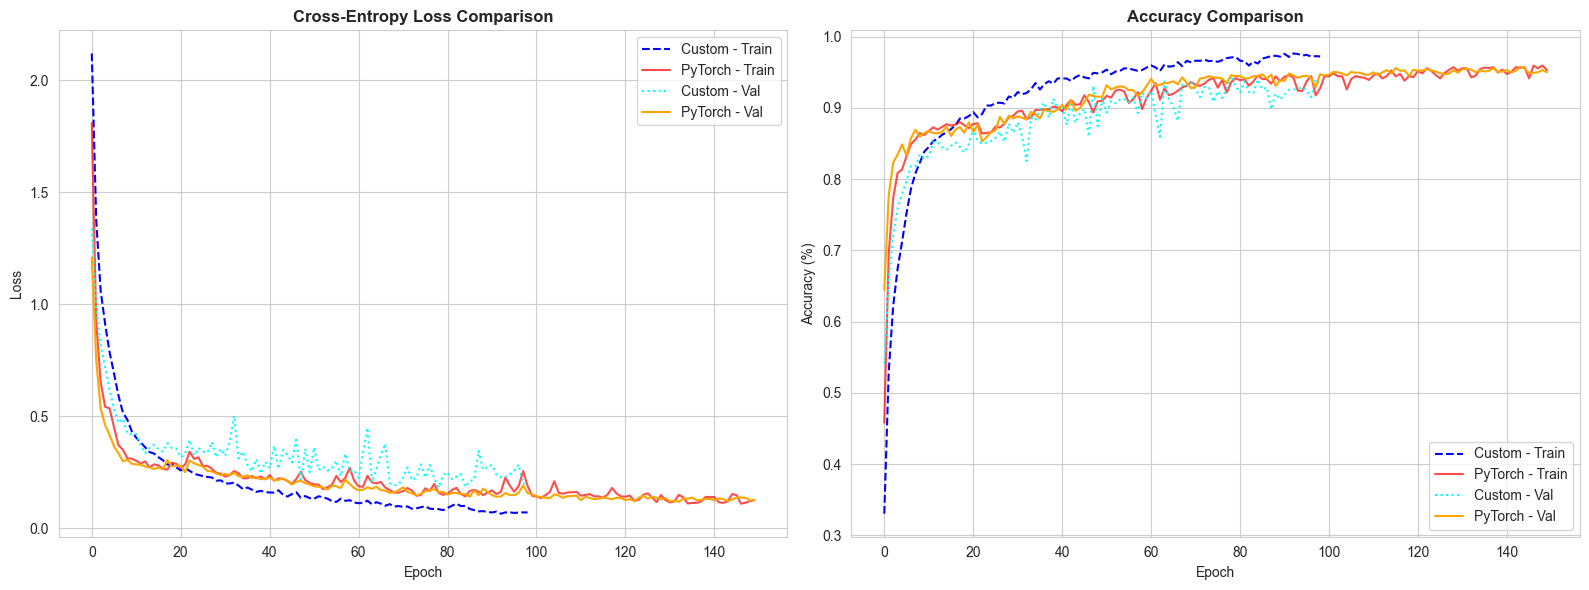

In [22]:
def plot_framework_comparison_curves(history_my, history_pt):
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(history_my["train_loss"], label="Custom - Train", color="blue", linestyle="--")
    ax1.plot(history_pt["train_loss"], label="PyTorch - Train", color="red", alpha=0.7)
    if history_my["val_loss"] and history_pt["val_loss"]:
        ax1.plot(history_my["val_loss"], label="Custom - Val", color="cyan", linestyle=":")
        ax1.plot(history_pt["val_loss"], label="PyTorch - Val", color="orange")
    ax1.set_title("Cross-Entropy Loss Comparison", fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax2.plot(history_my["train_acc"], label="Custom - Train", color="blue", linestyle="--")
    ax2.plot(history_pt["train_acc"], label="PyTorch - Train", color="red", alpha=0.7)
    if history_my["val_acc"] and history_pt["val_acc"]:
        ax2.plot(history_my["val_acc"], label="Custom - Val", color="cyan", linestyle=":")
        ax2.plot(history_pt["val_acc"], label="PyTorch - Val", color="orange")
    ax2.set_title("Accuracy Comparison", fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()

    plt.tight_layout()
    plt.show()


plot_framework_comparison_curves(history_my, history_pt)

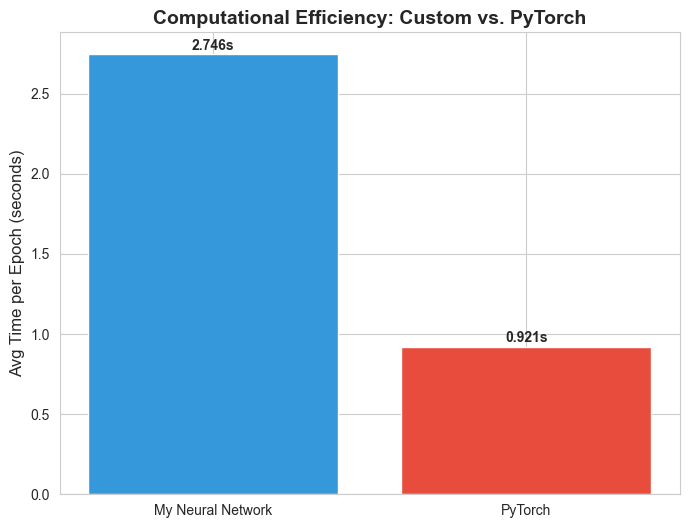

In [24]:
def plot_speed_comparison(history_my, history_pt):
    avg_time_my = np.mean(history_my["epoch_time"][1:])
    avg_time_pt = np.mean(history_pt["epoch_time"][1:])

    frameworks = ["My Neural Network", "PyTorch"]
    times = [avg_time_my, avg_time_pt]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(frameworks, times, color=["#3498db", "#e74c3c"])
    plt.ylabel("Avg Time per Epoch (seconds)", fontsize=12)
    plt.title("Computational Efficiency: Custom vs. PyTorch", fontweight="bold", fontsize=14)
    # Add data labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, yval + 0.01, f"{yval:.3f}s", ha="center", va="bottom", fontweight="bold"
        )
    plt.show()


plot_speed_comparison(history_my, history_pt)

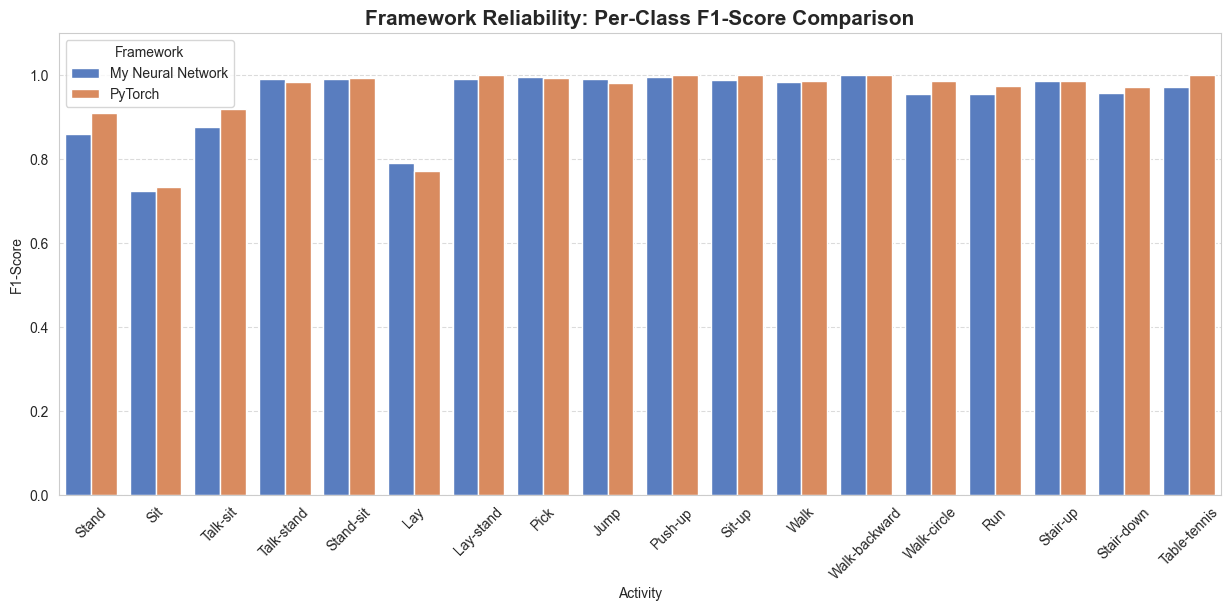

In [25]:
def plot_per_class_f1(y_true, y_probs_my, y_probs_pt, labels):
    y_true_idx = np.argmax(y_true, axis=1) if len(y_true.shape) > 1 else y_true

    f1_my = f1_score(y_true_idx, np.argmax(y_probs_my, axis=1), average=None)
    f1_pt = f1_score(y_true_idx, np.argmax(y_probs_pt, axis=1), average=None)

    df = pd.DataFrame({"Activity": labels, "My Neural Network": f1_my, "PyTorch": f1_pt}).melt(
        id_vars="Activity", var_name="Framework", value_name="F1-Score"
    )

    plt.figure(figsize=(15, 6))
    sns.barplot(data=df, x="Activity", y="F1-Score", hue="Framework", palette="muted")
    plt.xticks(rotation=45)
    plt.title("Framework Reliability: Per-Class F1-Score Comparison", fontweight="bold", fontsize=15)
    plt.ylim(0, 1.1)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


plot_per_class_f1(Y_test_raw, my_preds, pt_preds, labels_raw)

# 6. Comparsion with PatchTSTForClassification

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import PatchTSTConfig, PatchTSTForClassification

c:\Users\dziun\Documents\isa\isa-s1-mla-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class PatchTSTHARClassifier:
    def __init__(
        self,
        num_channels,
        num_classes,
        time_steps,
        lr=1e-4,
        patch_length=16,
        patch_stride=8,
        use_cls_token=True,
        pooling_type="mean",
        device=None,
    ):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        config = PatchTSTConfig(
            num_input_channels=num_channels,
            num_targets=num_classes,
            context_length=time_steps,
            patch_length=patch_length,
            patch_stride=patch_stride,
            use_cls_token=use_cls_token,
            pooling_type=pooling_type,
        )
        self.model = PatchTSTForClassification(config).to(self.device)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss()
        self.activity_labels = None

    def fit(
        self,
        x_train,
        y_train,
        x_val=None,
        y_val=None,
        epochs=1,
        batch_size=16,
        verbose=1,
        early_stopping_patience=None,
        early_stopping_min_delta=0.0,
    ):
        dataset = TensorDataset(
            torch.tensor(x_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long),
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        history = TrainingHistory()
        start_time = time()
        best_val_loss = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(epochs):
            self.model.train()
            epoch_loss = 0.0
            correct = 0
            total = 0
            epoch_start = time()

            for batch_x, batch_y in loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(past_values=batch_x)
                logits = outputs.prediction_logits
                loss = self.criterion(logits, batch_y)
                loss.backward()
                self.optimizer.step()

                batch_size_actual = batch_y.size(0)
                epoch_loss += loss.item() * batch_size_actual
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch_y).sum().item()
                total += batch_size_actual

            train_loss = epoch_loss / max(total, 1)
            train_acc = correct / max(total, 1)
            epoch_duration = time() - epoch_start
            val_loss = None
            val_acc = None

            if x_val is not None and y_val is not None:
                self.model.eval()
                val_loss_sum = 0.0
                val_correct = 0
                val_total = 0
                for i in range(0, len(x_val), batch_size):
                    batch_x = x_val[i : i + batch_size]
                    batch_y = y_val[i : i + batch_size]
                    xt = torch.tensor(batch_x, dtype=torch.float32).to(self.device)
                    yt = torch.tensor(batch_y, dtype=torch.long).to(self.device)
                    with torch.no_grad():
                        outputs = self.model(past_values=xt)
                        logits = outputs.prediction_logits
                        loss = self.criterion(logits, yt)
                    batch_size_actual = yt.size(0)
                    val_loss_sum += loss.item() * batch_size_actual
                    preds = torch.argmax(logits, dim=1)
                    val_correct += (preds == yt).sum().item()
                    val_total += batch_size_actual
                val_loss = val_loss_sum / max(val_total, 1)
                val_acc = val_correct / max(val_total, 1)

                if early_stopping_patience is not None:
                    if best_val_loss is None or val_loss < best_val_loss - early_stopping_min_delta:
                        best_val_loss = val_loss
                        best_epoch = epoch
                        patience_counter = 0
                    else:
                        patience_counter += 1

            history.update(
                train_loss=train_loss,
                train_acc=train_acc,
                epoch_time=epoch_duration,
                lr=self.optimizer.param_groups[0]["lr"],
                val_loss=val_loss,
                val_acc=val_acc,
            )

            if verbose > 0 and (epoch % verbose == 0 or epoch == epochs - 1):
                message = (
                    f"Epoch {epoch + 1}/{epochs} - "
                    f"Loss: {train_loss:.6f}, Acc: {train_acc:.4f}, "
                    f"Time: {epoch_duration:.2f}s"
                )
                if val_loss is not None and val_acc is not None:
                    message += f", Val Loss: {val_loss:.6f}, Val Acc: {val_acc:.4f}"
                print(message)

            if (
                early_stopping_patience is not None
                and val_loss is not None
                and patience_counter >= early_stopping_patience
            ):
                if verbose > 0 and best_val_loss is not None:
                    print(
                        f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.6f})."
                    )
                break

        if best_epoch is not None:
            history.best_epoch = best_epoch
        return history, time() - start_time

    def predict_proba(self, x, batch_size=32):
        self.model.eval()
        all_probs = []
        for i in range(0, len(x), batch_size):
            batch_x = x[i : i + batch_size]
            xt = torch.tensor(batch_x, dtype=torch.float32).to(self.device)
            with torch.no_grad():
                outputs = self.model(past_values=xt)
                logits = outputs.prediction_logits
                probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
        return np.concatenate(all_probs, axis=0)

    def predict(self, x):
        return np.argmax(self.predict_proba(x), axis=1)

In [8]:
X_patch_train, X_patch_val, X_patch_test             = X_raw_train_T,  X_raw_val_T,  X_raw_test_T
Y_patch_train, Y_patch_val, Y_patch_test             = Y_raw_train_int, Y_raw_val_int, Y_raw_test_int
lengths_patch_train, lengths_patch_val, lengths_patch_test = lengths_raw_train, lengths_raw_val, lengths_raw_test

patch_model = PatchTSTHARClassifier(
    num_channels=X_patch_train.shape[2],
    num_classes=num_classes,
    time_steps=X_patch_train.shape[1],
    lr=1e-4,
)
patch_model.activity_labels = labels_raw
epochs_patch                   = 150
batch_size_patch               = 16
early_stopping_patience_patch  = 20
early_stopping_min_delta_patch = 1e-3

print("Training PatchTST model...")
history_patch, time_patch = patch_model.fit(
    X_patch_train,
    Y_patch_train,
    x_val=X_patch_val,
    y_val=Y_patch_val,
    epochs=epochs_patch,
    batch_size=batch_size_patch,
    verbose=1,
    early_stopping_patience=early_stopping_patience_patch,
    early_stopping_min_delta=early_stopping_min_delta_patch,
)
print(f"PatchTST training time: {time_patch:.2f} seconds")

Training PatchTST model...
Epoch 1/150 - Loss: 1.344972, Acc: 0.5654, Time: 19.35s, Val Loss: 0.720171, Val Acc: 0.7627
Epoch 2/150 - Loss: 0.507223, Acc: 0.8289, Time: 18.82s, Val Loss: 0.443890, Val Acc: 0.8606
Epoch 3/150 - Loss: 0.369601, Acc: 0.8739, Time: 18.77s, Val Loss: 0.421971, Val Acc: 0.8530
Epoch 4/150 - Loss: 0.283704, Acc: 0.9036, Time: 18.77s, Val Loss: 0.342891, Val Acc: 0.8835
Epoch 5/150 - Loss: 0.220651, Acc: 0.9283, Time: 18.78s, Val Loss: 0.286389, Val Acc: 0.9096
Epoch 6/150 - Loss: 0.176542, Acc: 0.9367, Time: 18.79s, Val Loss: 0.249545, Val Acc: 0.9227
Epoch 7/150 - Loss: 0.158536, Acc: 0.9467, Time: 18.78s, Val Loss: 0.279515, Val Acc: 0.9102
Epoch 8/150 - Loss: 0.123584, Acc: 0.9574, Time: 18.80s, Val Loss: 0.241357, Val Acc: 0.9271
Epoch 9/150 - Loss: 0.113535, Acc: 0.9630, Time: 18.82s, Val Loss: 0.285282, Val Acc: 0.9205
Epoch 10/150 - Loss: 0.102579, Acc: 0.9668, Time: 18.82s, Val Loss: 0.246924, Val Acc: 0.9254
Epoch 11/150 - Loss: 0.097912, Acc: 0.9670

In [9]:
predictions_patch = patch_model.predict_proba(X_patch_test)
Y_patch_test_oh = to_one_hot(Y_patch_test, num_classes)
y_patch_true = np.argmax(Y_patch_test_oh, axis=1)
y_patch_pred = np.argmax(predictions_patch, axis=1)

## 6.1 Evaluation

### 6.1.1 Confusion matrix

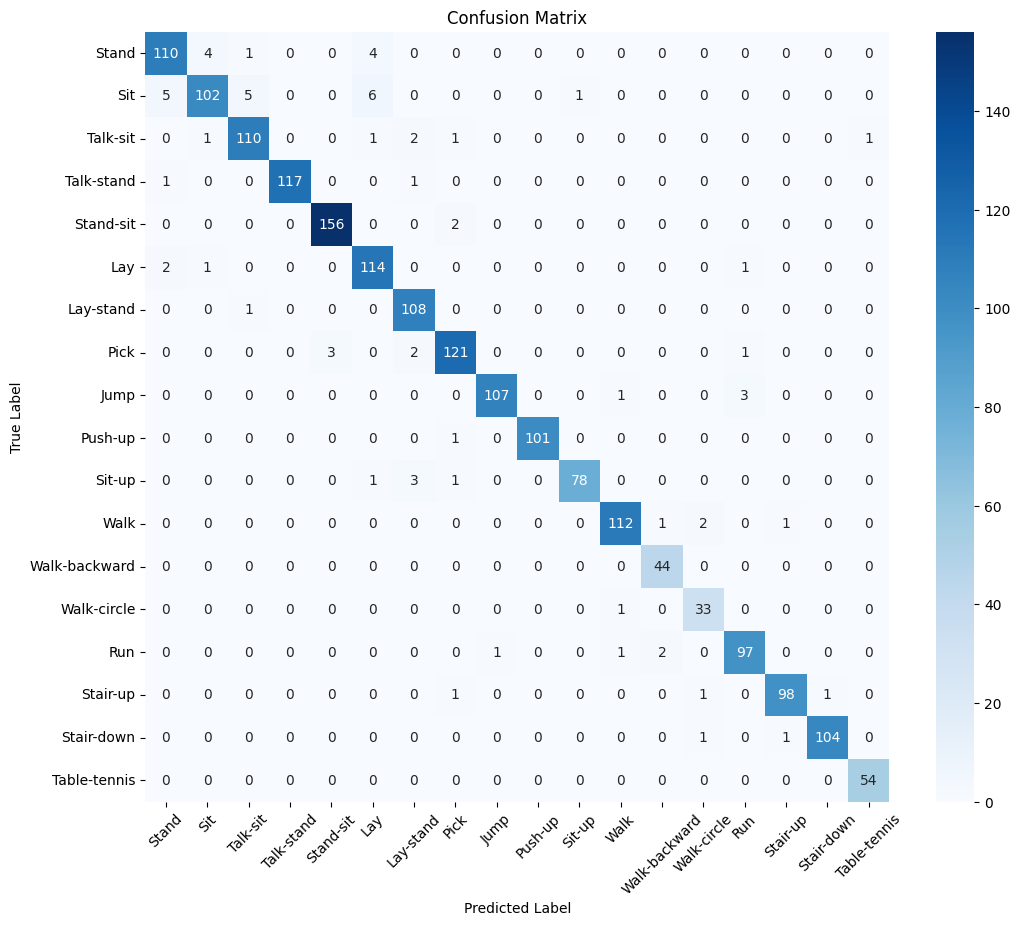

In [10]:
plot_confusion_matrix(
    y_patch_true,
    y_patch_pred,
    patch_model,
    lengths_test=lengths_patch_test,
    activity_map=patch_model.activity_labels,
 )

### 6.1.2 Metrics per activity

In [11]:
global_m_patch, class_df_patch = get_detailed_metrics(
    Y_patch_test_oh, predictions_patch, activity_map
 )

In [12]:
print(class_df_patch)

               precision    recall  f1-score    support
Stand           0.932203  0.924370  0.928270  119.00000
Sit             0.944444  0.857143  0.898678  119.00000
Talk-sit        0.940171  0.948276  0.944206  116.00000
Talk-stand      1.000000  0.983193  0.991525  119.00000
Stand-sit       0.981132  0.987342  0.984227  158.00000
Lay             0.904762  0.966102  0.934426  118.00000
Lay-stand       0.931034  0.990826  0.960000  109.00000
Pick            0.952756  0.952756  0.952756  127.00000
Jump            0.990741  0.963964  0.977169  111.00000
Push-up         1.000000  0.990196  0.995074  102.00000
Sit-up          0.987342  0.939759  0.962963   83.00000
Walk            0.973913  0.965517  0.969697  116.00000
Walk-backward   0.936170  1.000000  0.967033   44.00000
Walk-circle     0.891892  0.970588  0.929577   34.00000
Run             0.950980  0.960396  0.955665  101.00000
Stair-up        0.980000  0.970297  0.975124  101.00000
Stair-down      0.990476  0.981132  0.985782  10

### 6.1.2.1 F1-score

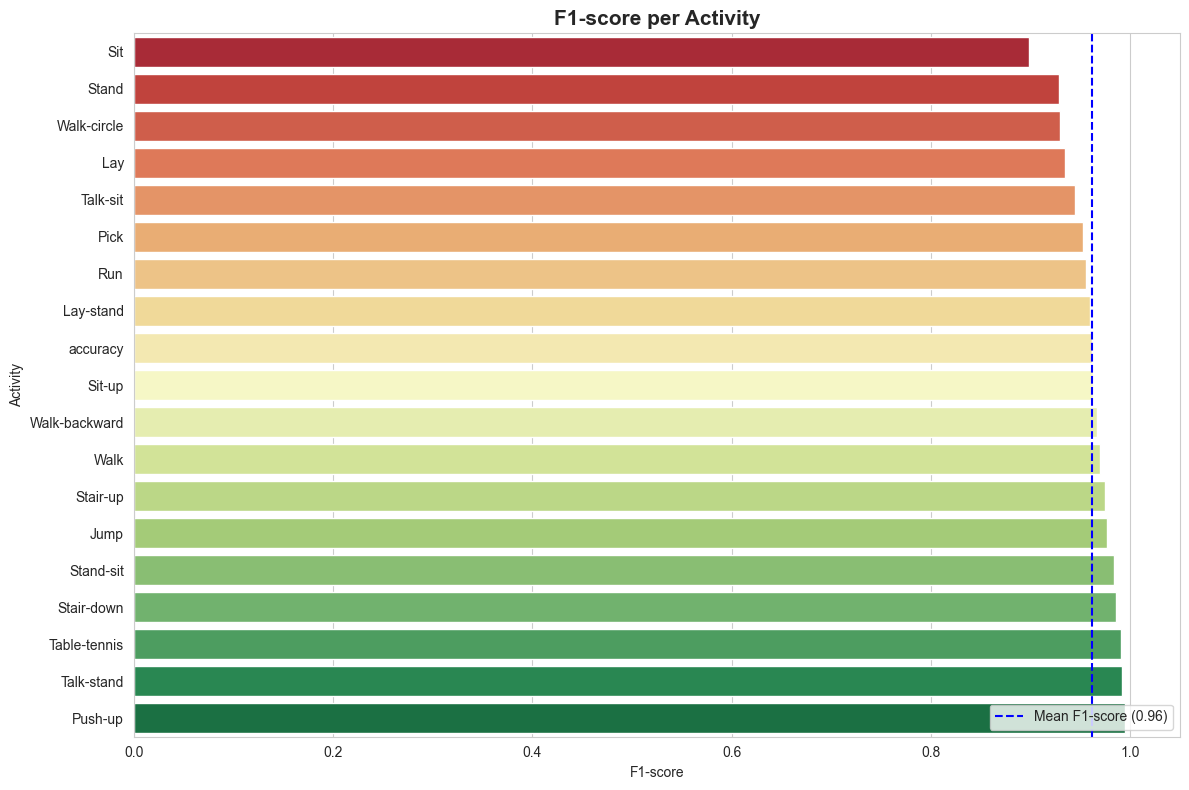

In [18]:
plot_class_performance(class_df_patch, metric="f1-score")

### 6.1.2.2 Recall

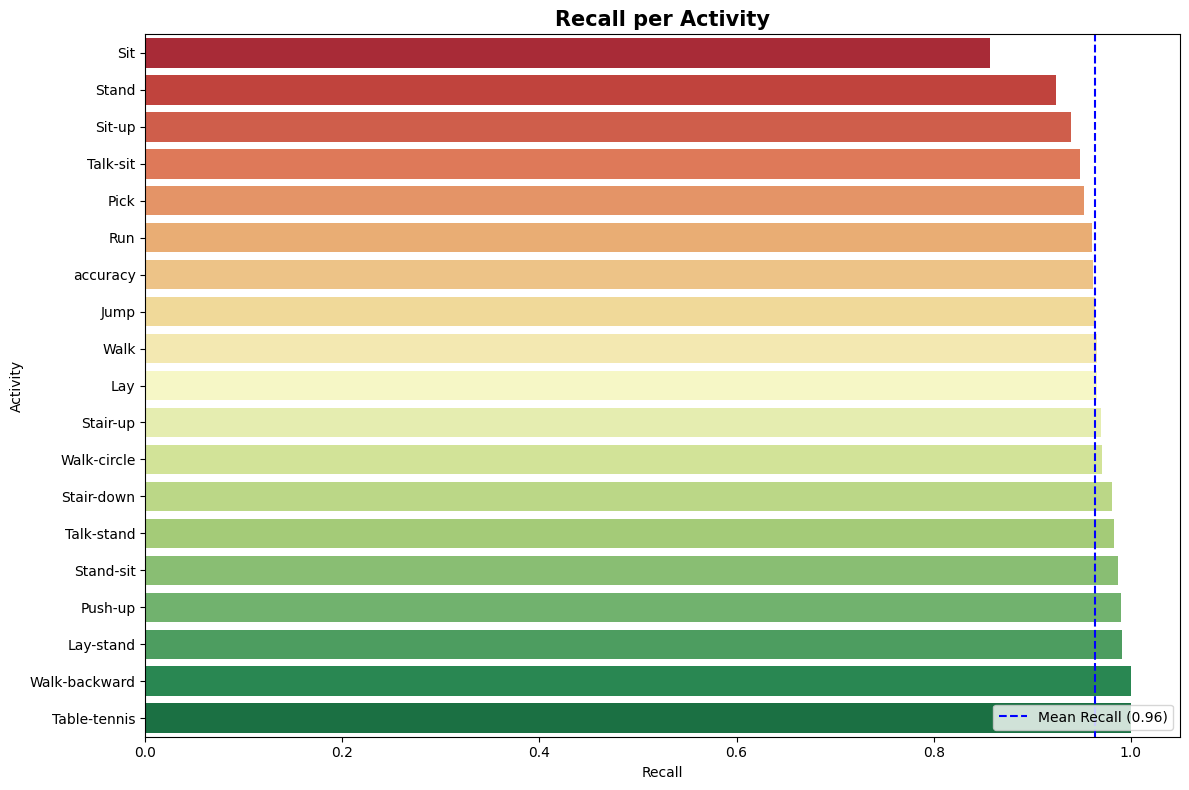

In [14]:
plot_class_performance(class_df_patch, metric="recall")

### 6.1.2.3 Precision

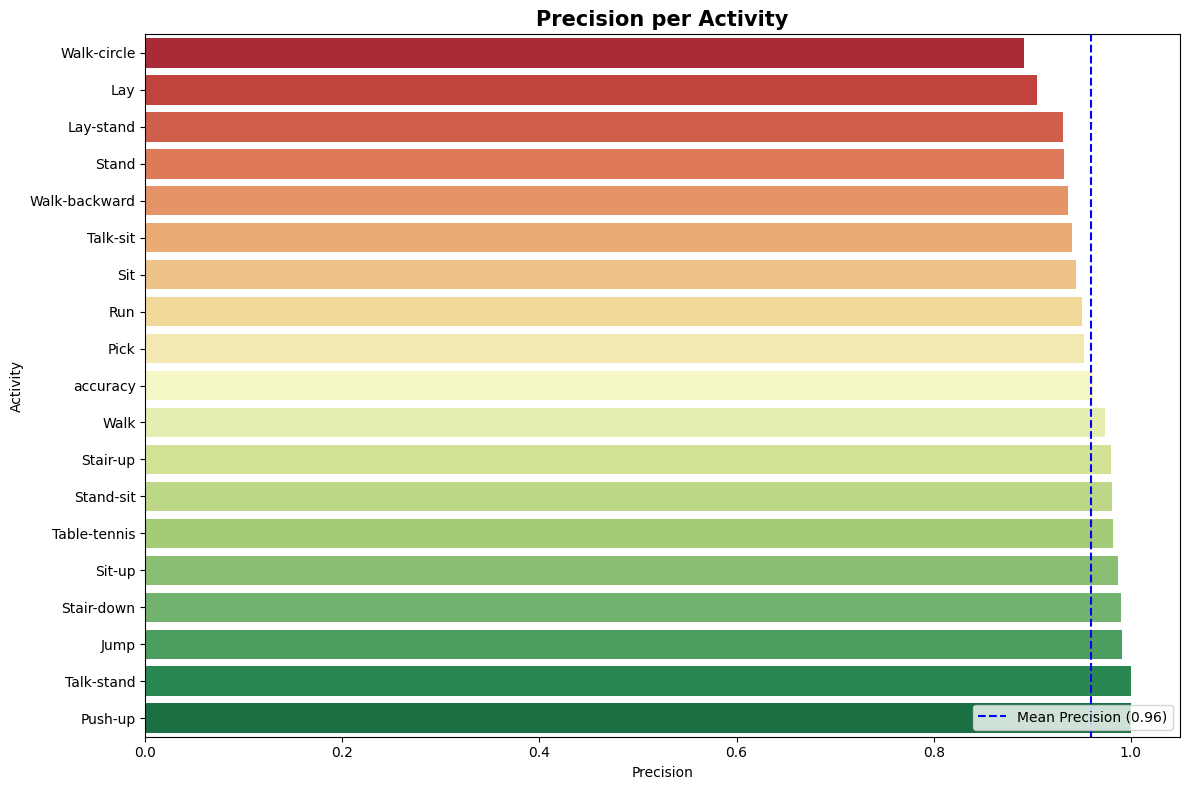

In [15]:
plot_class_performance(class_df_patch, metric="precision")

### 6.1.2.4 Most confused classes by total misses

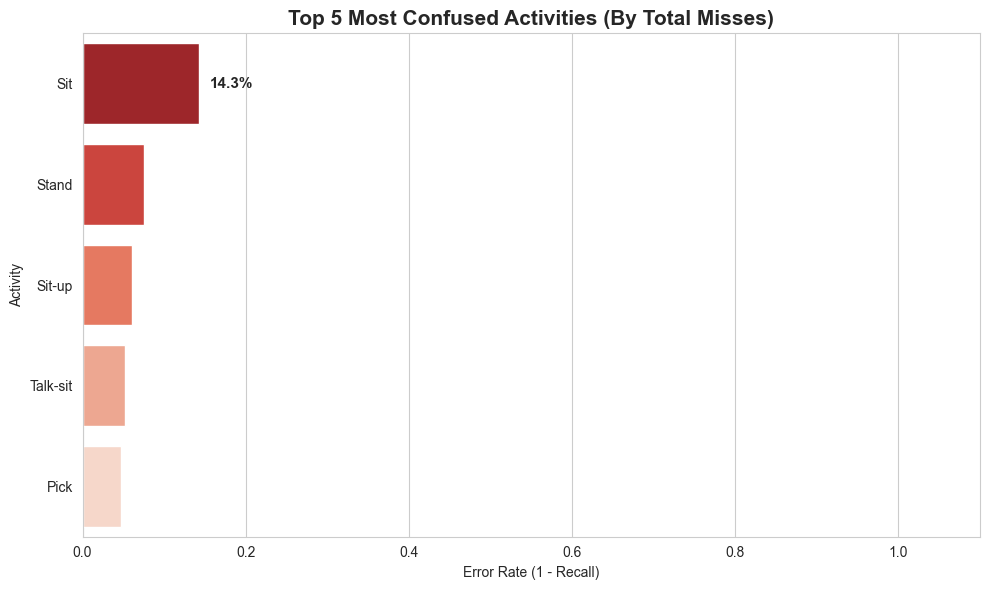

In [16]:
plot_most_confused_classes(class_df_patch, top_n=5)

### 6.1.2.5 Top mutually confused classes

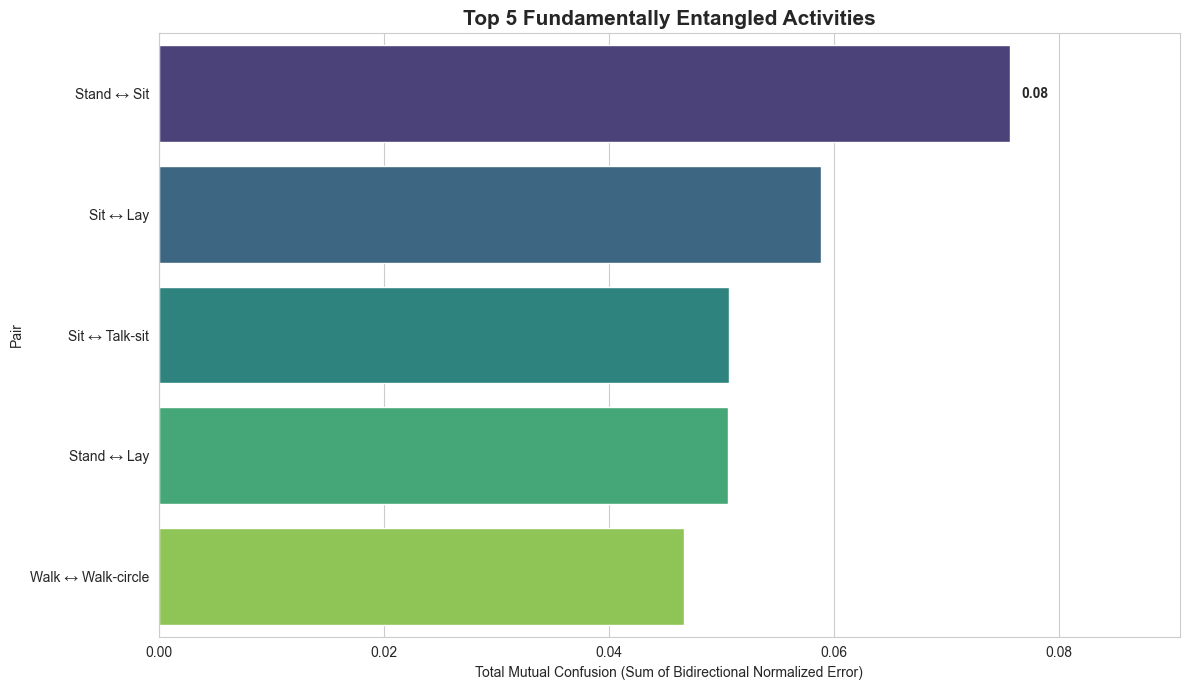

In [17]:
plot_top_mutual_confusions(Y_patch_test_oh, predictions_patch, activity_map, top_n=5)

# 7. Comprasion with GRU

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class _GRUModel(nn.Module):
    def __init__(self, num_channels, num_classes, hidden_dim=128, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_channels,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0,
        )
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths=None):
        out, _ = self.gru(x)
        if lengths is not None:
            lengths = torch.clamp(lengths.long(), min=1, max=out.size(1))
            idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(2))
            out = out.gather(1, idx).squeeze(1)
        else:
            out = out[:, -1, :]
        out = self.bn(out)
        out = self.dropout(out)
        return self.fc(out)


class GRUHARClassifier:
    def __init__(
        self,
        num_channels,
        num_classes,
        hidden_dim=128,
        num_layers=2,
        lr=1e-3,
        device=None,
    ):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = _GRUModel(num_channels, num_classes, hidden_dim, num_layers).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss()
        self.activity_labels = None

    def fit(
        self,
        x_train,
        y_train,
        lengths_train=None,
        x_val=None,
        y_val=None,
        lengths_val=None,
        epochs=10,
        batch_size=32,
        verbose=1,
        early_stopping_patience=None,
        early_stopping_min_delta=0.0,
    ):
        if lengths_train is not None:
            dataset = TensorDataset(
                torch.tensor(x_train, dtype=torch.float32),
                torch.tensor(y_train, dtype=torch.long),
                torch.tensor(lengths_train, dtype=torch.long),
            )
        else:
            dataset = TensorDataset(
                torch.tensor(x_train, dtype=torch.float32),
                torch.tensor(y_train, dtype=torch.long),
            )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        history = TrainingHistory()
        start_time = time()
        best_val_loss = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(epochs):
            self.model.train()
            epoch_loss = 0.0
            correct = 0
            total = 0
            epoch_start = time()

            for batch in loader:
                if lengths_train is not None:
                    batch_x, batch_y, batch_lengths = batch
                    batch_lengths = batch_lengths.to(self.device)
                else:
                    batch_x, batch_y = batch
                    batch_lengths = None
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(batch_x, lengths=batch_lengths)
                loss = self.criterion(logits, batch_y)
                loss.backward()
                self.optimizer.step()

                batch_size_actual = batch_y.size(0)
                epoch_loss += loss.item() * batch_size_actual
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch_y).sum().item()
                total += batch_size_actual

            train_loss = epoch_loss / max(total, 1)
            train_acc = correct / max(total, 1)
            epoch_duration = time() - epoch_start
            val_loss = None
            val_acc = None

            if x_val is not None and y_val is not None:
                self.model.eval()
                val_loss_sum = 0.0
                val_correct = 0
                val_total = 0
                for i in range(0, len(x_val), batch_size):
                    bx = x_val[i : i + batch_size]
                    by = y_val[i : i + batch_size]
                    xt = torch.tensor(bx, dtype=torch.float32).to(self.device)
                    yt = torch.tensor(by, dtype=torch.long).to(self.device)
                    if lengths_val is not None:
                        bl = torch.tensor(lengths_val[i : i + batch_size], dtype=torch.long).to(self.device)
                    else:
                        bl = None
                    with torch.no_grad():
                        logits_v = self.model(xt, lengths=bl)
                        loss_v = self.criterion(logits_v, yt)
                    bs = yt.size(0)
                    val_loss_sum += loss_v.item() * bs
                    val_correct += (torch.argmax(logits_v, dim=1) == yt).sum().item()
                    val_total += bs
                val_loss = val_loss_sum / max(val_total, 1)
                val_acc = val_correct / max(val_total, 1)

                if early_stopping_patience is not None:
                    if best_val_loss is None or val_loss < best_val_loss - early_stopping_min_delta:
                        best_val_loss = val_loss
                        best_epoch = epoch
                        patience_counter = 0
                    else:
                        patience_counter += 1

            history.update(
                train_loss=train_loss,
                train_acc=train_acc,
                epoch_time=epoch_duration,
                lr=self.optimizer.param_groups[0]["lr"],
                val_loss=val_loss,
                val_acc=val_acc,
            )

            if verbose > 0 and (epoch % verbose == 0 or epoch == epochs - 1):
                message = (
                    f"Epoch {epoch + 1}/{epochs} - "
                    f"Loss: {train_loss:.6f}, Acc: {train_acc:.4f}, "
                    f"Time: {epoch_duration:.2f}s"
                )
                if val_loss is not None and val_acc is not None:
                    message += f", Val Loss: {val_loss:.6f}, Val Acc: {val_acc:.4f}"
                print(message)

            if (
                early_stopping_patience is not None
                and val_loss is not None
                and patience_counter >= early_stopping_patience
            ):
                if verbose > 0 and best_val_loss is not None:
                    print(
                        f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.6f})."
                    )
                break

        if best_epoch is not None:
            history.best_epoch = best_epoch
        return history, time() - start_time

    def predict_proba(self, x, lengths=None, batch_size=32):
        self.model.eval()
        all_probs = []
        for i in range(0, len(x), batch_size):
            batch_x = x[i : i + batch_size]
            xt = torch.tensor(batch_x, dtype=torch.float32).to(self.device)
            if lengths is not None:
                bl = torch.tensor(lengths[i : i + batch_size], dtype=torch.long).to(self.device)
            else:
                bl = None
            with torch.no_grad():
                logits = self.model(xt, lengths=bl)
                probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
        return np.concatenate(all_probs, axis=0)

    def predict(self, x, lengths=None):
        return np.argmax(self.predict_proba(x, lengths=lengths), axis=1)

In [20]:
# Reuse the shared stratified split from the global setup cell.
X_gru_train, X_gru_val, X_gru_test             = X_raw_train_T,  X_raw_val_T,  X_raw_test_T
Y_gru_train, Y_gru_val, Y_gru_test             = Y_raw_train_int, Y_raw_val_int, Y_raw_test_int
lengths_gru_train, lengths_gru_val, lengths_gru_test = lengths_raw_train, lengths_raw_val, lengths_raw_test

Y_gru_test_oh = to_one_hot(Y_gru_test, num_classes)
labels_gru    = labels_raw

In [22]:
gru_model = GRUHARClassifier(
    num_channels=X_gru_train.shape[2],
    num_classes=num_classes,
    hidden_dim=128,
    num_layers=2,
    lr=1e-3,
 )
gru_model.activity_labels = labels_gru

epochs_gru = 150
batch_size_gru = 32
early_stopping_patience_gru = 20
early_stopping_min_delta_gru = 1e-3

print("Training GRU model...")
history_gru, time_gru = gru_model.fit(
    X_gru_train,
    Y_gru_train,
    lengths_train=lengths_gru_train,
    x_val=X_gru_val,
    y_val=Y_gru_val,
    lengths_val=lengths_gru_val,
    epochs=epochs_gru,
    batch_size=batch_size_gru,
    verbose=1,
    early_stopping_patience=early_stopping_patience_gru,
    early_stopping_min_delta=early_stopping_min_delta_gru,
 )
print(f"GRU training time: {time_gru:.2f} seconds")

Training GRU model...
Epoch 1/150 - Loss: 2.635087, Acc: 0.1437, Time: 4.64s, Val Loss: 2.267037, Val Acc: 0.2014
Epoch 2/150 - Loss: 2.037848, Acc: 0.2785, Time: 4.62s, Val Loss: 1.619404, Val Acc: 0.3696
Epoch 3/150 - Loss: 1.265851, Acc: 0.5059, Time: 4.60s, Val Loss: 0.953336, Val Acc: 0.6004
Epoch 4/150 - Loss: 0.832780, Acc: 0.6625, Time: 4.60s, Val Loss: 0.680892, Val Acc: 0.7322
Epoch 5/150 - Loss: 0.644919, Acc: 0.7347, Time: 4.57s, Val Loss: 0.588402, Val Acc: 0.7550
Epoch 6/150 - Loss: 0.560599, Acc: 0.7605, Time: 4.61s, Val Loss: 0.505613, Val Acc: 0.7790
Epoch 7/150 - Loss: 0.465566, Acc: 0.7962, Time: 4.61s, Val Loss: 0.498473, Val Acc: 0.7768
Epoch 8/150 - Loss: 0.462795, Acc: 0.7926, Time: 4.59s, Val Loss: 0.438071, Val Acc: 0.8008
Epoch 9/150 - Loss: 0.407277, Acc: 0.8127, Time: 4.61s, Val Loss: 0.431531, Val Acc: 0.7970
Epoch 10/150 - Loss: 0.376397, Acc: 0.8323, Time: 4.60s, Val Loss: 0.360702, Val Acc: 0.8454
Epoch 11/150 - Loss: 0.360437, Acc: 0.8398, Time: 4.60s, 

In [23]:
predictions_gru = gru_model.predict_proba(X_gru_test, lengths=lengths_gru_test)
y_gru_true = Y_gru_test
y_gru_pred = np.argmax(predictions_gru, axis=1)

## 7.1 Evaluation

### 7.1.1 Confusion matrix

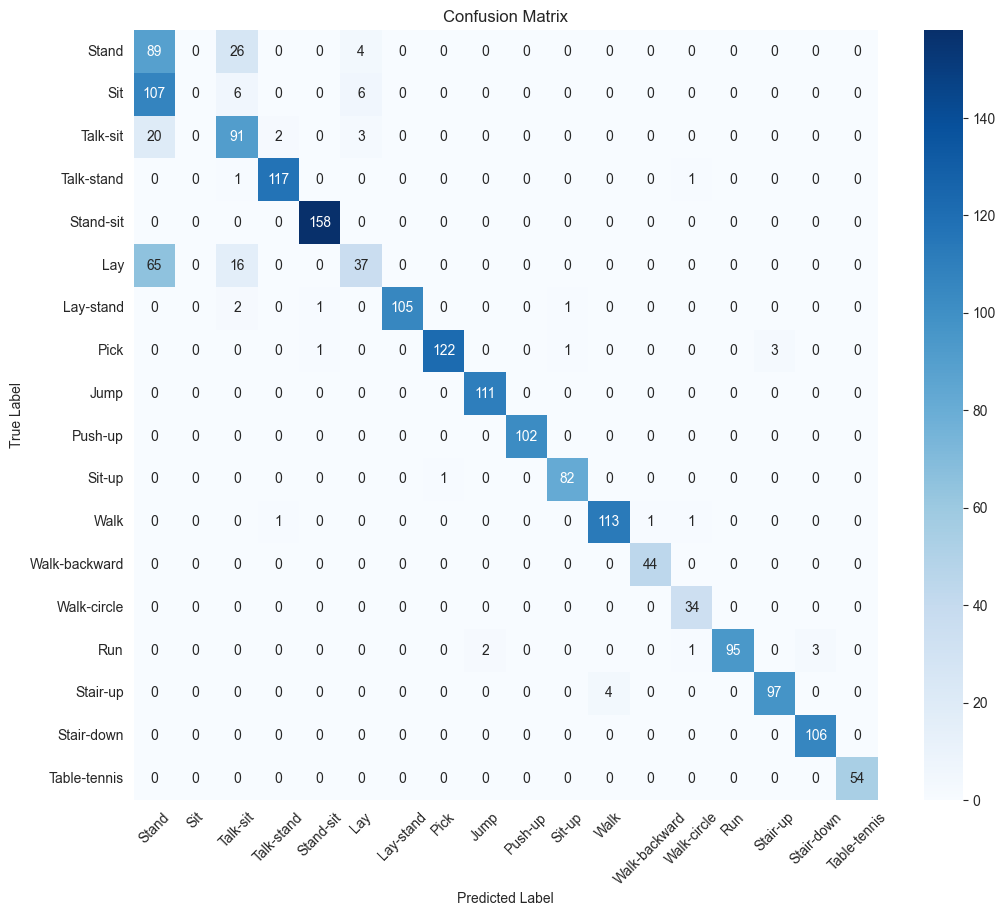

In [24]:
plot_confusion_matrix(
    y_gru_true,
    y_gru_pred,
    gru_model,
    lengths_test=lengths_gru_test,
    activity_map=gru_model.activity_labels,
 )

### 7.1.2 Metrics per activity

In [25]:
global_m_gru, class_df_gru = get_detailed_metrics(
    Y_gru_test_oh, predictions_gru, activity_map
)


In [26]:
print(class_df_gru)

               precision    recall  f1-score     support
Stand           0.316726  0.747899  0.445000  119.000000
Sit             0.000000  0.000000  0.000000  119.000000
Talk-sit        0.640845  0.784483  0.705426  116.000000
Talk-stand      0.975000  0.983193  0.979079  119.000000
Stand-sit       0.987500  1.000000  0.993711  158.000000
Lay             0.740000  0.313559  0.440476  118.000000
Lay-stand       1.000000  0.963303  0.981308  109.000000
Pick            0.991870  0.960630  0.976000  127.000000
Jump            0.982301  1.000000  0.991071  111.000000
Push-up         1.000000  1.000000  1.000000  102.000000
Sit-up          0.976190  0.987952  0.982036   83.000000
Walk            0.965812  0.974138  0.969957  116.000000
Walk-backward   0.977778  1.000000  0.988764   44.000000
Walk-circle     0.918919  1.000000  0.957746   34.000000
Run             1.000000  0.940594  0.969388  101.000000
Stair-up        0.970000  0.960396  0.965174  101.000000
Stair-down      0.972477  1.000

### 7.1.2.1 F1-score

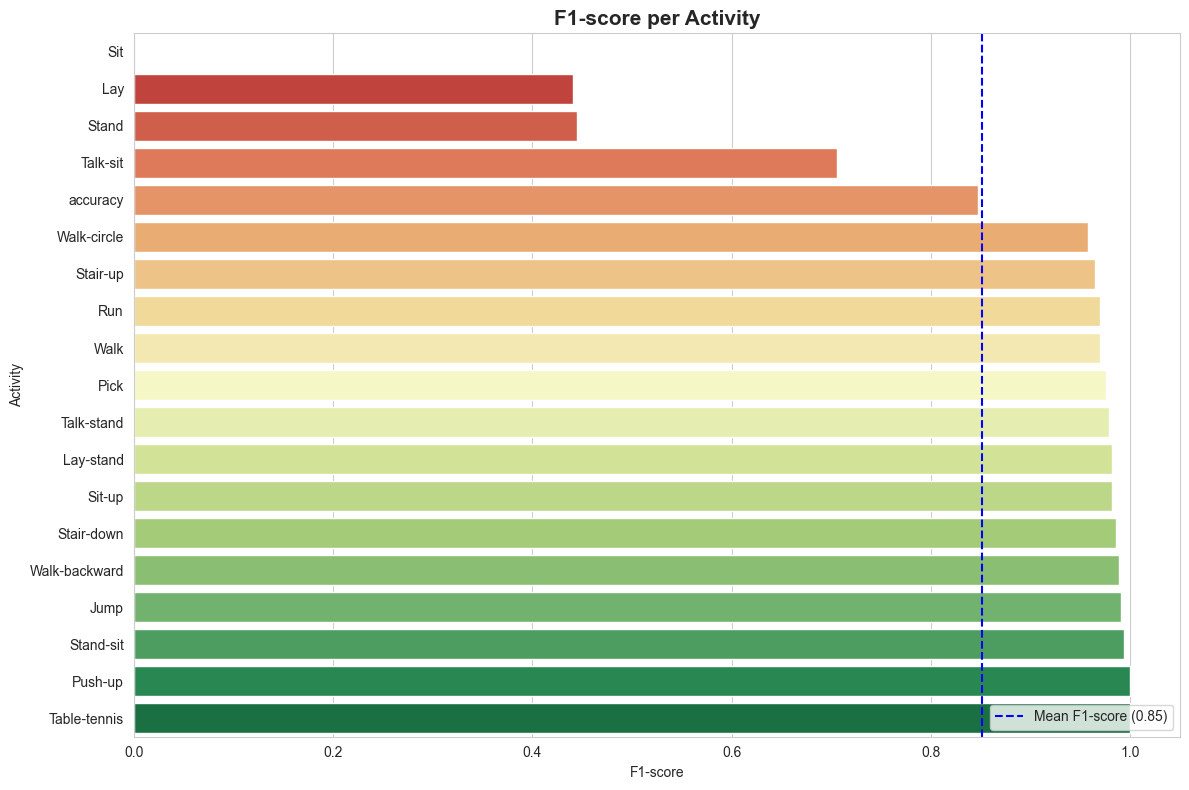

In [27]:
plot_class_performance(class_df_gru, metric="f1-score")


### 7.1.2.2 Recall

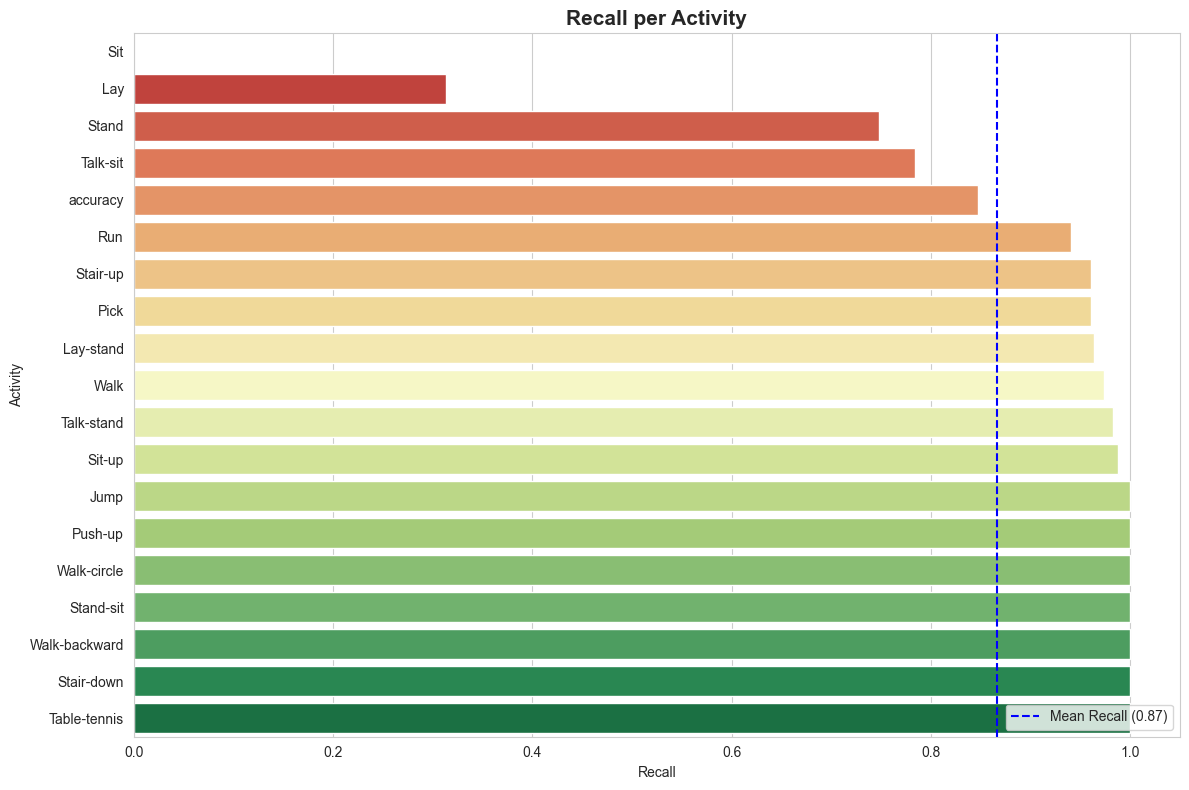

In [28]:
plot_class_performance(class_df_gru, metric="recall")


### 7.1.2.3 Precision

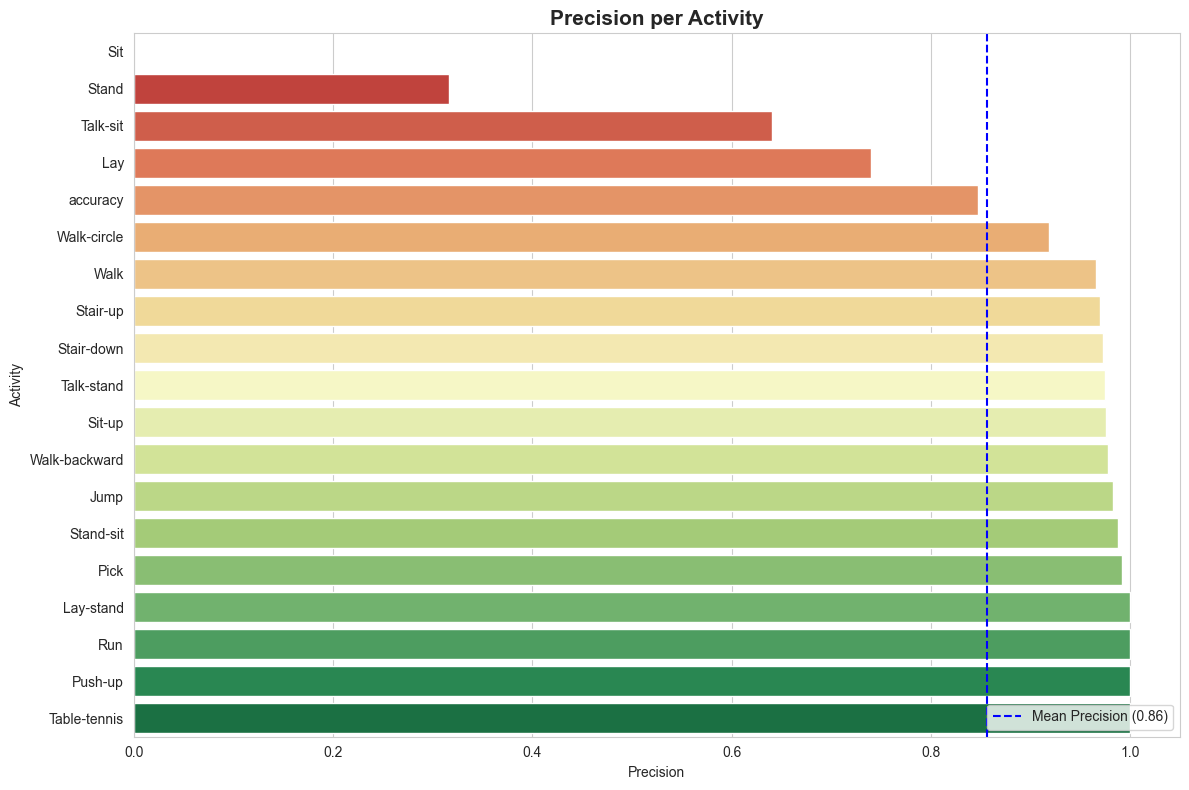

In [29]:
plot_class_performance(class_df_gru, metric="precision")


### 7.1.2.4 Most confused classes by total misses

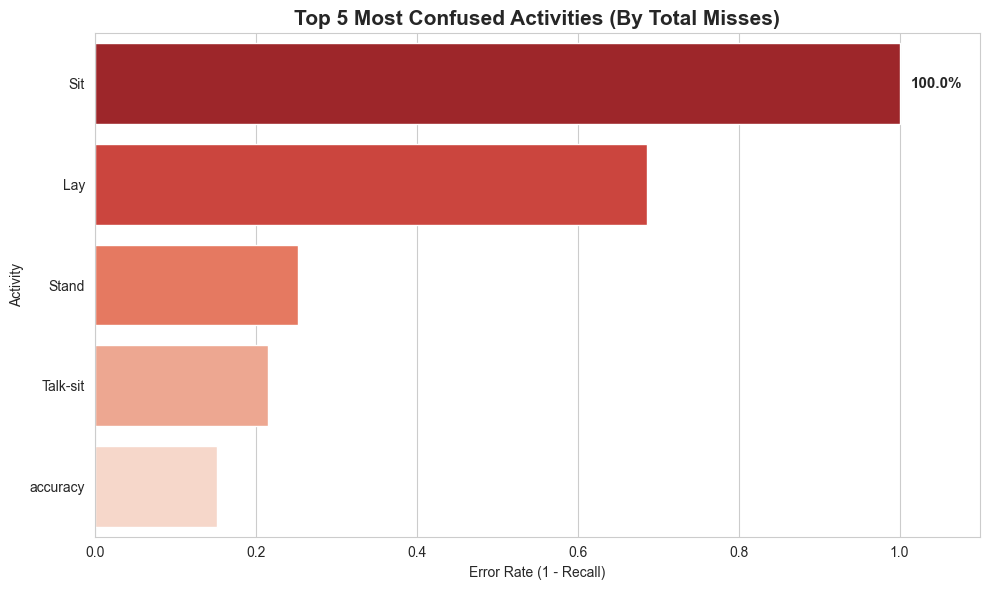

In [30]:
plot_most_confused_classes(class_df_gru, top_n=5)


### 7.1.2.5 Top mutually confused classes

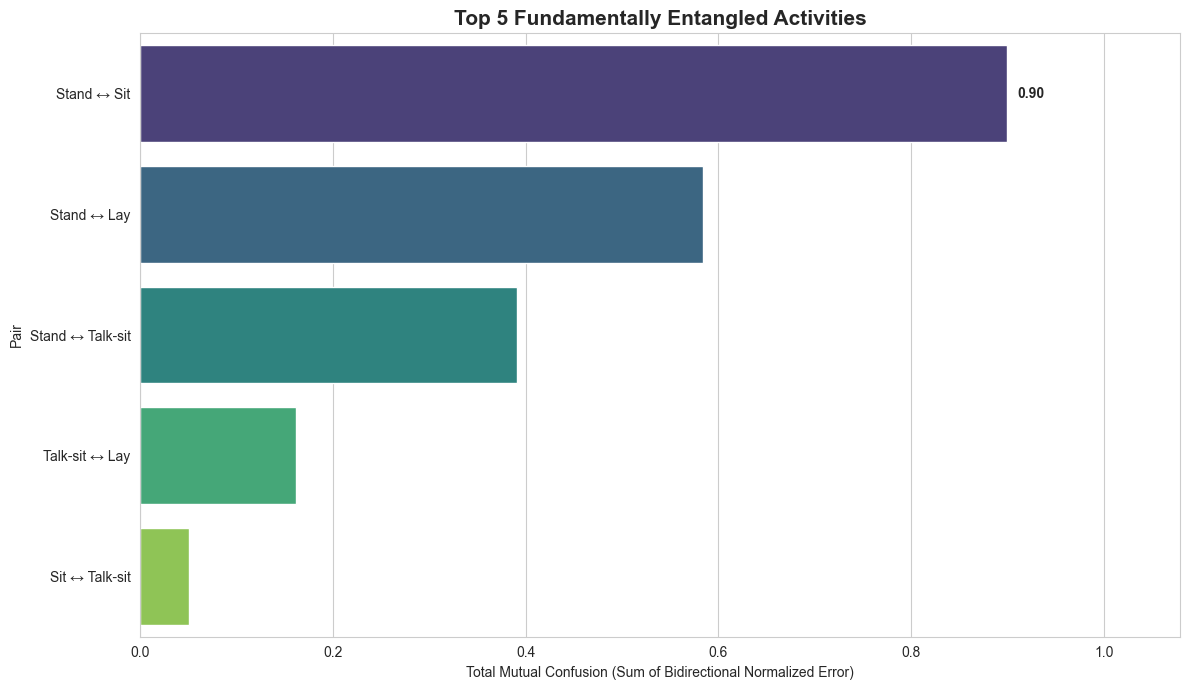

In [31]:
plot_top_mutual_confusions(Y_gru_test_oh, predictions_gru, activity_map, top_n=5)


# CPU vs GPU performance

In [ ]:
def compare_gpu_vs_cpu(X, Y, model: Network, epochs=1, batch_size=64, verbose=5):
    if not backend._cupy_runtime_ok:
        print("GPU runtime not available. Skipping GPU vs CPU comparison.")
        return -1, -1
    backend.configure(policy=BackendPolicy(use_gpu=False), dataset_bytes=0)
    model.reset()
    X_cpu, Y_cpu = backend.asarray(X), backend.asarray(Y)
    _, cpu_time = model.fit(X_cpu, Y_cpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    model.reset()
    backend.configure(policy=BackendPolicy(use_gpu=True, min_gpu_bytes=0), dataset_bytes=10)
    X_gpu, Y_gpu = backend.asarray(X), backend.asarray(Y)
    _, gpu_time = model.fit(X_gpu, Y_gpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return cpu_time, gpu_time


def plot_performance_benchmark(cpu_time, gpu_time):
    sns.set_style("whitegrid")
    plt.figure(figsize=(9, 6))

    devices = ["CPU (NumPy)", "GPU (CuPy)"]
    times = [cpu_time, gpu_time]
    speedup = cpu_time / gpu_time

    ax = sns.barplot(x=devices, y=times, palette=["#4C72B0", "#C44E52"], hue=devices, legend=False)

    ax.bar_label(ax.containers[0], fmt="%.2fs", padding=8, fontweight="bold", fontsize=12)

    props = {"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "gray"}
    plt.text(
        0.5,
        0.95,
        f"GPU Speedup: {speedup:.2f}x Faster",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        horizontalalignment="center",
        bbox=props,
        color="#C44E52",
        fontweight="bold",
    )

    plt.title("Hardware Acceleration Benchmark: CPU vs GPU", fontsize=15, pad=20)
    plt.ylabel("Total Execution Time (seconds)", fontsize=12)
    plt.ylim(0, max(times) * 1.2)
    plt.tight_layout()

In [ ]:
# X_RAW and SCALER_RAW already available from the global setup cell.
model_comparison_gpu_cpu = prepare_model(labels=labels_raw, scaler=SCALER_RAW)
cpu_time, gpu_time = compare_gpu_vs_cpu(
    X_raw_train, Y_raw_train, model_comparison_gpu_cpu, epochs=5, batch_size=256, verbose=1
)
print(f"CPU time: {cpu_time:.2f} seconds")
print(f"GPU time: {gpu_time:.2f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")
plot_performance_benchmark(cpu_time, gpu_time)